# 🛒 Modelo de Probabilidad de Recompra — Online Retail II

**Contexto de negocio:**  
Retailer online con sede en UK (2009–2011) que vende artículos de regalo al por mayor y al detalle. El objetivo es construir un modelo supervisado que estime la probabilidad de que un cliente vuelva a comprar, para diseñar acciones comerciales de **fidelización** (alta probabilidad) y **retención** (baja probabilidad).

**Estructura del notebook:**
1. Setup y librerías
2. Carga de datos
3. Calidad de datos — nulos, duplicados, outliers, anomalías
4. EDA profundo — temporal, geográfico, producto, cliente, cohortes
5. Feature engineering RFM extendido (14 variables)
6. Preparación del dataset de modelado
7. Benchmark de 7 algoritmos base
8. Optimización con Optuna (búsqueda bayesiana)
9. Evaluación completa — AUC, PR, Lift, Calibración, Brier
10. Explicabilidad SHAP — global, dependence, waterfall
11. Segmentación accionable y exportación


---
## 1. Setup y librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.model_selection      import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model         import LogisticRegression
from sklearn.ensemble             import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.preprocessing        import StandardScaler, RobustScaler
from sklearn.calibration          import CalibratedClassifierCV, calibration_curve
from sklearn.metrics              import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, brier_score_loss
)
from sklearn.pipeline             import Pipeline
from sklearn.inspection           import permutation_importance

# ── Boosting ──────────────────────────────────────────────────────────────
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print('CatBoost no disponible — se usarán 6 algoritmos')

# ── Optimización y explicabilidad ─────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

# ── Config global ─────────────────────────────────────────────────────────
SEED      = 42
PALETTE   = ['#1B4F72','#148F77','#D4AC0D','#CB4335','#7D3C98','#1A5276','#117A65']
PLT_STYLE = 'seaborn-v0_8-whitegrid'
plt.style.use(PLT_STYLE)
sns.set_palette('husl')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.4f}'.format)

print('✓ Librerías cargadas correctamente')
print(f'  CatBoost disponible: {HAS_CATBOOST}')

✓ Librerías cargadas correctamente
  CatBoost disponible: True


---
## 2. Carga de datos

In [2]:
DATA_PATH = 'online_retail_II.xlsx'

xl = pd.ExcelFile(DATA_PATH)
print('Hojas Excel:', xl.sheet_names)

frames = []
for sheet in xl.sheet_names:
    tmp = pd.read_excel(DATA_PATH, sheet_name=sheet)
    tmp['sheet'] = sheet
    frames.append(tmp)
    print(f'  {sheet}: {len(tmp):,} filas')

df_raw = pd.concat(frames, ignore_index=True)
df_raw.to_pickle('online_retail.pkl')   # Cache para ejecuciones futuras

print(f'\nTotal: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Memoria: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB')

Hojas Excel: ['Year 2009-2010', 'Year 2010-2011']
  Year 2009-2010: 525,461 filas
  Year 2010-2011: 541,910 filas

Total: 1,067,371 filas × 9 columnas
Memoria: 328.4 MB


In [ ]:
# Para iteraciones posteriores:
# df_raw = pd.read_pickle('online_retail.pkl')

---
## 3. Calidad de datos

### 3.1 Inspección inicial

In [3]:
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom,Year 2009-2010
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.6500,"13,085.0000",United Kingdom,Year 2009-2010
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom,Year 2009-2010
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.9500,"13,085.0000",United Kingdom,Year 2009-2010
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.5500,"13,085.0000",United Kingdom,Year 2009-2010
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.7500,"13,085.0000",United Kingdom,Year 2009-2010


In [4]:
df_raw.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
 8   sheet        1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 73.3+ MB


In [5]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,"1,067,371.0000","53,628.0000","537,434.0000","1,350.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"1,067,371.0000",NaN,NaN,NaN,9.9389,"-80,995.0000",1.0000,3.0000,10.0000,"80,995.0000",172.7058
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394029,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,"1,067,371.0000",NaN,NaN,NaN,4.6494,"-53,594.3600",1.2500,2.1000,4.1500,"38,970.0000",123.5531
Customer ID,"824,364.0000",NaN,NaN,NaN,"15,324.6385","12,346.0000","13,975.0000","15,255.0000","16,797.0000","18,287.0000","1,697.4645"
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sheet,1067371,2,Year 2010-2011,541910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print('=== Resumen del dataset ===')
print(f'Período:           {df_raw["InvoiceDate"].min().date()} → {df_raw["InvoiceDate"].max().date()}')
print(f'Facturas únicas:   {df_raw["Invoice"].astype(str).nunique():,}')
print(f'Clientes únicos:   {df_raw["Customer ID"].nunique():,}  (con ID)')
print(f'Productos únicos:  {df_raw["StockCode"].nunique():,}')
print(f'Países únicos:     {df_raw["Country"].nunique():,}')

=== Resumen del dataset ===
Período:           2009-12-01 → 2011-12-09
Facturas únicas:   53,628
Clientes únicos:   5,942  (con ID)
Productos únicos:  5,305
Países únicos:     43


### 3.2 Valores nulos

              Nulos  % del total
Description    4382       0.4100
Customer ID  243007      22.7700


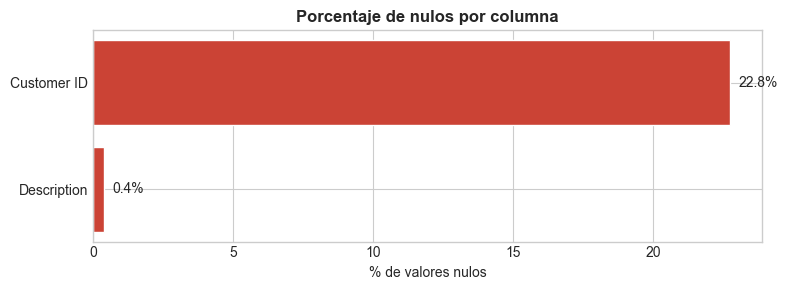

In [7]:
nulos     = df_raw.isnull().sum()
nulos_pct = nulos / len(df_raw) * 100
tabla_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct.round(2)})
print(tabla_nulos[tabla_nulos['Nulos'] > 0].to_string())

fig, ax = plt.subplots(figsize=(8, 3))
cols_nulos = nulos_pct[nulos_pct > 0].sort_values()
bars = ax.barh(cols_nulos.index, cols_nulos.values, color=PALETTE[3], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por columna', fontweight='bold')
plt.tight_layout(); plt.show()

### 3.3 Duplicados exactos

In [8]:
n_dup = df_raw.duplicated().sum()
print(f'Filas duplicadas exactas: {n_dup:,}  ({n_dup/len(df_raw)*100:.3f}%)')
print('\nEjemplo de duplicados encontrados:')
df_raw[df_raw.duplicated(keep=False)].sort_values(['Invoice','StockCode']).head(4)

Filas duplicadas exactas: 12,133  (1.137%)

Ejemplo de duplicados encontrados:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sheet
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.9500,"16,329.0000",United Kingdom,Year 2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.9500,"16,329.0000",United Kingdom,Year 2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010


### 3.4 Cancelaciones y anomalías

Cancelaciones (Invoice empieza en C):  19,494  (1.8%)
Price <= 0:                            6,207
Quantity <= 0 (no cancelaciones):      3,457
Stock codes internos (POST, M, D…):    5,749


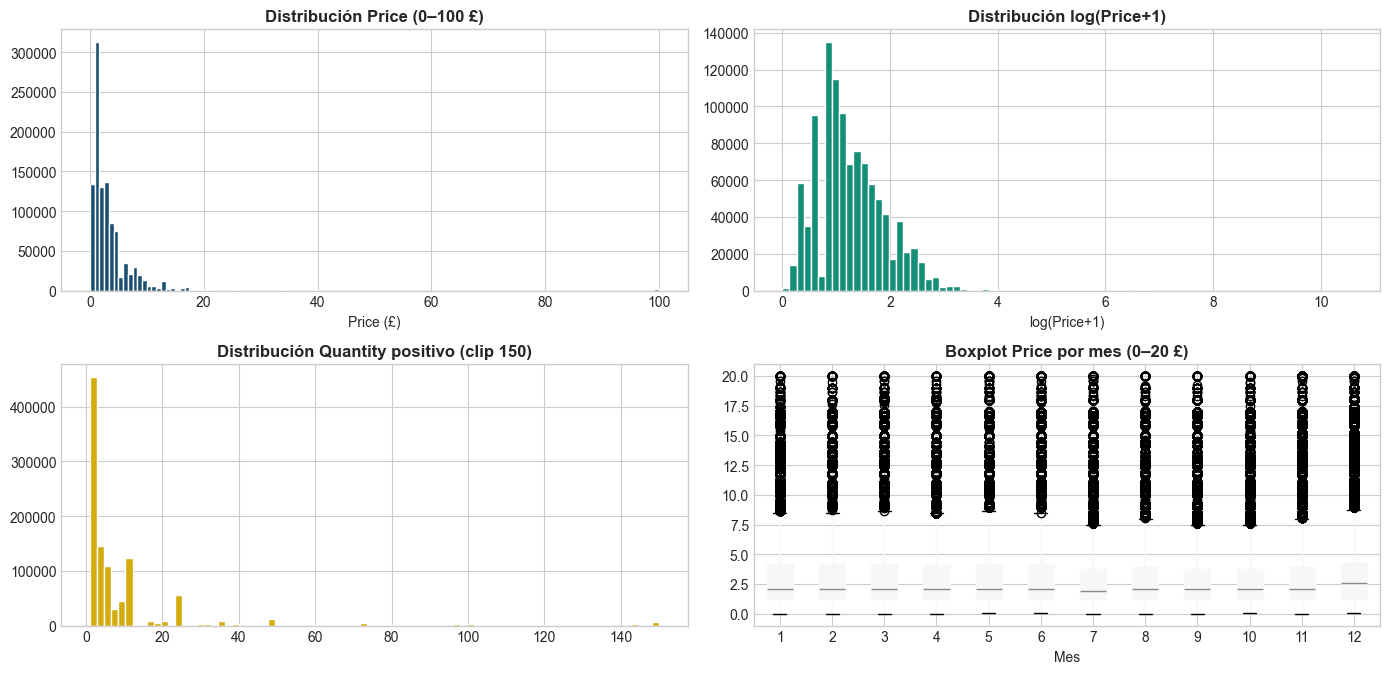

In [9]:
df_raw['Invoice'] = df_raw['Invoice'].astype(str)
mask_cancel = df_raw['Invoice'].str.startswith('C')

print(f'Cancelaciones (Invoice empieza en C):  {mask_cancel.sum():,}  ({mask_cancel.mean()*100:.1f}%)')
print(f'Price <= 0:                            {(df_raw["Price"] <= 0).sum():,}')
print(f'Quantity <= 0 (no cancelaciones):      {((df_raw["Quantity"] <= 0) & ~mask_cancel).sum():,}')

INTERNAL_CODES = {'POST','D','C2','M','BANK CHARGES','PADS','DOT','AMAZONFEE','S','CRUK','TEST001','TEST002'}
mask_internal = df_raw['StockCode'].isin(INTERNAL_CODES)
print(f'Stock codes internos (POST, M, D…):    {mask_internal.sum():,}')

# Distribución de Price y Quantity para detectar outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Price sin recorte
df_raw[df_raw['Price'] > 0]['Price'].clip(upper=100).hist(
    bins=120, ax=axes[0,0], color=PALETTE[0], edgecolor='white')
axes[0,0].set_title('Distribución Price (0–100 £)', fontweight='bold')
axes[0,0].set_xlabel('Price (£)')

# Price log
np.log1p(df_raw[df_raw['Price'] > 0]['Price']).hist(
    bins=80, ax=axes[0,1], color=PALETTE[1], edgecolor='white')
axes[0,1].set_title('Distribución log(Price+1)', fontweight='bold')
axes[0,1].set_xlabel('log(Price+1)')

# Quantity sin cancelaciones
df_raw[(df_raw['Quantity'] > 0) & ~mask_cancel]['Quantity'].clip(upper=150).hist(
    bins=80, ax=axes[1,0], color=PALETTE[2], edgecolor='white')
axes[1,0].set_title('Distribución Quantity positivo (clip 150)', fontweight='bold')

# Boxplot Price por mes
tmp = df_raw[(df_raw['Price'] > 0) & (df_raw['Price'] < 20)].copy()
tmp['Month'] = tmp['InvoiceDate'].dt.month
tmp.boxplot(column='Price', by='Month', ax=axes[1,1], patch_artist=True)
axes[1,1].set_title('Boxplot Price por mes (0–20 £)', fontweight='bold')
axes[1,1].set_xlabel('Mes')
plt.suptitle('')
plt.tight_layout(); plt.show()

### 3.5 Limpieza — Decisiones documentadas

| Criterio de exclusión | Razón | Impacto estimado |
|---|---|---|
| Invoice empieza por 'C' | Devoluciones/cancelaciones — no son compras reales | ~16% filas |
| Customer ID nulo | Sin ID no podemos construir perfil de cliente | ~22% filas |
| Price ≤ 0 | Precio cero o negativo — transacciones erróneas | <1% |
| Quantity ≤ 0 (sin cancelaciones) | Ajustes de inventario, no ventas | <1% |
| StockCodes internos | POST, M, D… son cargos administrativos, no productos | <0.1% |
| Duplicados exactos | Registros duplicados en el sistema fuente | ~0.5% |

In [10]:
df = (
    df_raw
    .copy()
    .drop_duplicates()
    .loc[lambda x: ~x['Invoice'].str.startswith('C')]
    .dropna(subset=['Customer ID'])
    .loc[lambda x: x['Price'] > 0]
    .loc[lambda x: x['Quantity'] > 0]
    .loc[lambda x: ~x['StockCode'].isin(INTERNAL_CODES)]
    .reset_index(drop=True)
)

df['Customer ID']  = df['Customer ID'].astype(int)
df['Revenue']      = df['Quantity'] * df['Price']
df['InvoiceDate']  = pd.to_datetime(df['InvoiceDate'])
df['Year']         = df['InvoiceDate'].dt.year
df['Month']        = df['InvoiceDate'].dt.month
df['Quarter']      = df['InvoiceDate'].dt.quarter
df['DayOfWeek']    = df['InvoiceDate'].dt.dayofweek
df['Hour']         = df['InvoiceDate'].dt.hour
df['WeekOfYear']   = df['InvoiceDate'].dt.isocalendar().week.astype(int)

print(f'Dataset limpio: {len(df):,} filas  ({len(df)/len(df_raw)*100:.1f}% del original)')
print(f'Clientes únicos: {df["Customer ID"].nunique():,}')
print(f'Revenue — media: £{df["Revenue"].mean():.2f}  |  mediana: £{df["Revenue"].median():.2f}  |  p99: £{df["Revenue"].quantile(0.99):.2f}')

Dataset limpio: 790,739 filas  (74.1% del original)
Clientes únicos: 5,861
Revenue — media: £21.98  |  mediana: £11.90  |  p99: £201.60


---
## 4. EDA Profundo

### 4.1 Evolución temporal — Estacionalidad

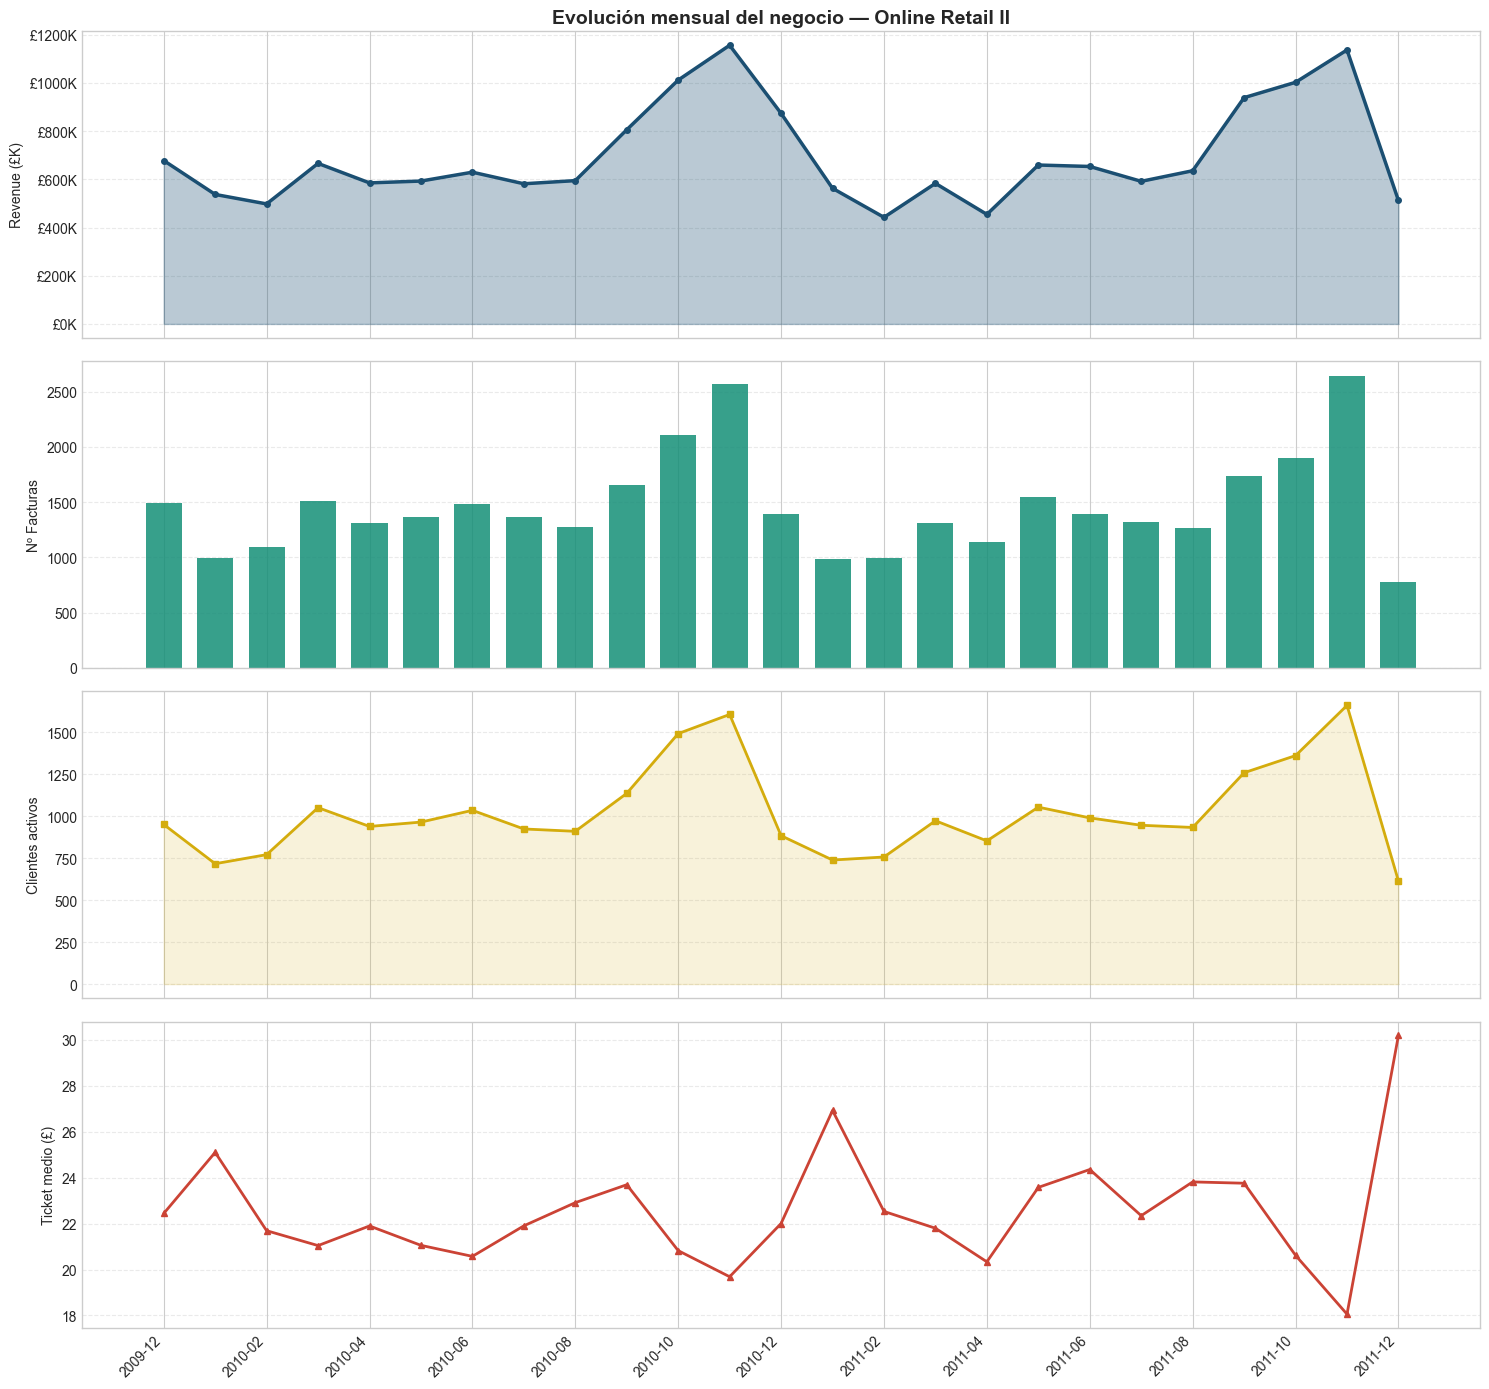

Revenue por año:
            sum    mean   count
Year                           
2009   677.9000 22.4000   30208
2010 8,531.2000 21.6000  394950
2011 8,172.0000 22.4000  365581


In [11]:
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M')).agg(
    Revenue      = ('Revenue',      'sum'),
    Facturas     = ('Invoice',      'nunique'),
    Clientes     = ('Customer ID',  'nunique'),
    TicketMedio  = ('Revenue',      'mean'),
).reset_index()
monthly['InvoiceDateStr'] = monthly['InvoiceDate'].astype(str)

fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

axes[0].fill_between(range(len(monthly)), monthly['Revenue']/1000, alpha=0.3, color=PALETTE[0])
axes[0].plot(range(len(monthly)), monthly['Revenue']/1000, color=PALETTE[0], lw=2.5, marker='o', ms=4)
axes[0].set_ylabel('Revenue (£K)')
axes[0].set_title('Evolución mensual del negocio — Online Retail II', fontsize=14, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}K'))

axes[1].bar(range(len(monthly)), monthly['Facturas'], color=PALETTE[1], alpha=0.85, width=0.7)
axes[1].set_ylabel('Nº Facturas')

axes[2].plot(range(len(monthly)), monthly['Clientes'], color=PALETTE[2], lw=2, marker='s', ms=4)
axes[2].fill_between(range(len(monthly)), monthly['Clientes'], alpha=0.15, color=PALETTE[2])
axes[2].set_ylabel('Clientes activos')

axes[3].plot(range(len(monthly)), monthly['TicketMedio'], color=PALETTE[3], lw=2, marker='^', ms=4)
axes[3].set_ylabel('Ticket medio (£)')

step = max(1, len(monthly)//12)
axes[3].set_xticks(range(0, len(monthly), step))
axes[3].set_xticklabels(monthly['InvoiceDateStr'][::step], rotation=45, ha='right')

for ax in axes:
    ax.grid(axis='y', alpha=0.4, linestyle='--')

plt.tight_layout(); plt.show()

print('Revenue por año:')
print(df.groupby('Year')['Revenue'].agg(['sum','mean','count']).apply(
    lambda x: x if x.name in ['mean','count'] else x/1000).round(1))

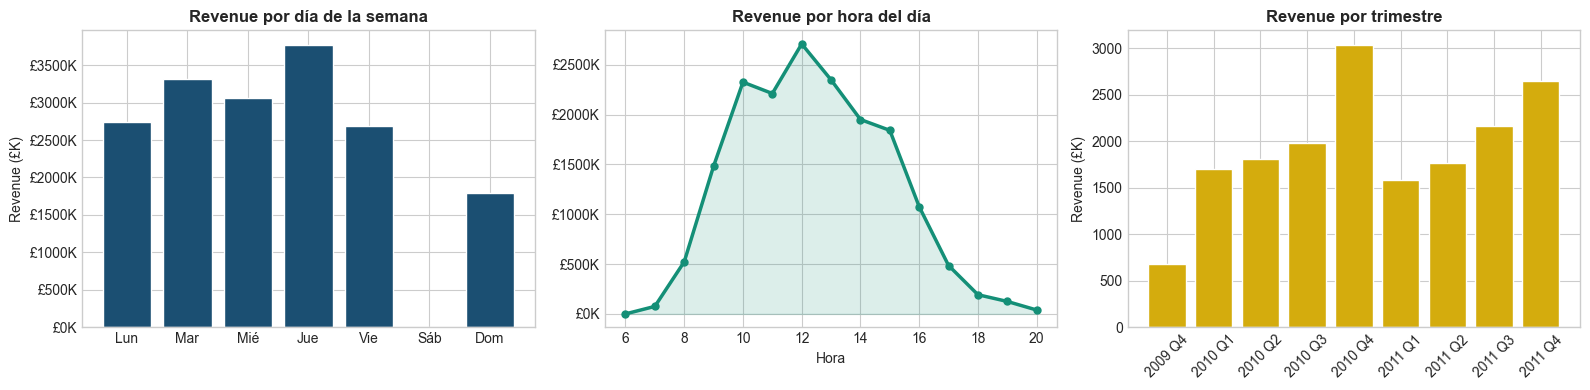

In [12]:
# Patrones por día de semana y hora
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Día de semana
dow_names = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
rev_dow = df.groupby('DayOfWeek')['Revenue'].sum()
axes[0].bar([dow_names[i] for i in rev_dow.index], rev_dow.values/1000,
            color=PALETTE[0], edgecolor='white')
axes[0].set_title('Revenue por día de la semana', fontweight='bold')
axes[0].set_ylabel('Revenue (£K)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}K'))

# Hora del día
rev_hour = df.groupby('Hour')['Revenue'].sum()
axes[1].plot(rev_hour.index, rev_hour.values/1000, color=PALETTE[1], lw=2.5, marker='o', ms=5)
axes[1].fill_between(rev_hour.index, rev_hour.values/1000, alpha=0.15, color=PALETTE[1])
axes[1].set_title('Revenue por hora del día', fontweight='bold')
axes[1].set_xlabel('Hora')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}K'))

# Por trimestre
rev_q = df.groupby(['Year','Quarter'])['Revenue'].sum().reset_index()
rev_q['label'] = rev_q['Year'].astype(str) + ' Q' + rev_q['Quarter'].astype(str)
axes[2].bar(rev_q['label'], rev_q['Revenue']/1000, color=PALETTE[2], edgecolor='white')
axes[2].set_title('Revenue por trimestre', fontweight='bold')
axes[2].set_ylabel('Revenue (£K)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

### 4.2 Análisis geográfico

=== TOP 15 países por Revenue ===
                        Revenue  Clientes  Facturas  TicketMedio  PrecioMedio  Revenue_pct  Rev_por_cliente
Country                                                                                                    
United Kingdom  14,568,178.4600      5336     33374      20.4422       2.9391      83.8159       2,730.1684
EIRE               592,606.2100         5       539      38.1809       3.5385       3.4095     118,521.2420
Netherlands        549,951.0100        22       216     110.3876       2.3448       3.1641      24,997.7732
Germany            388,401.3200       107       756      24.2554       2.7179       2.2346       3,629.9189
France             315,120.3100        94       591      23.7111       2.6048       1.8130       3,352.3437
Australia          168,417.1600        15        89      93.3059       2.7921       0.9690      11,227.8107
Spain               98,789.2200        41       147      27.3806       3.1162       0.5684       2,409

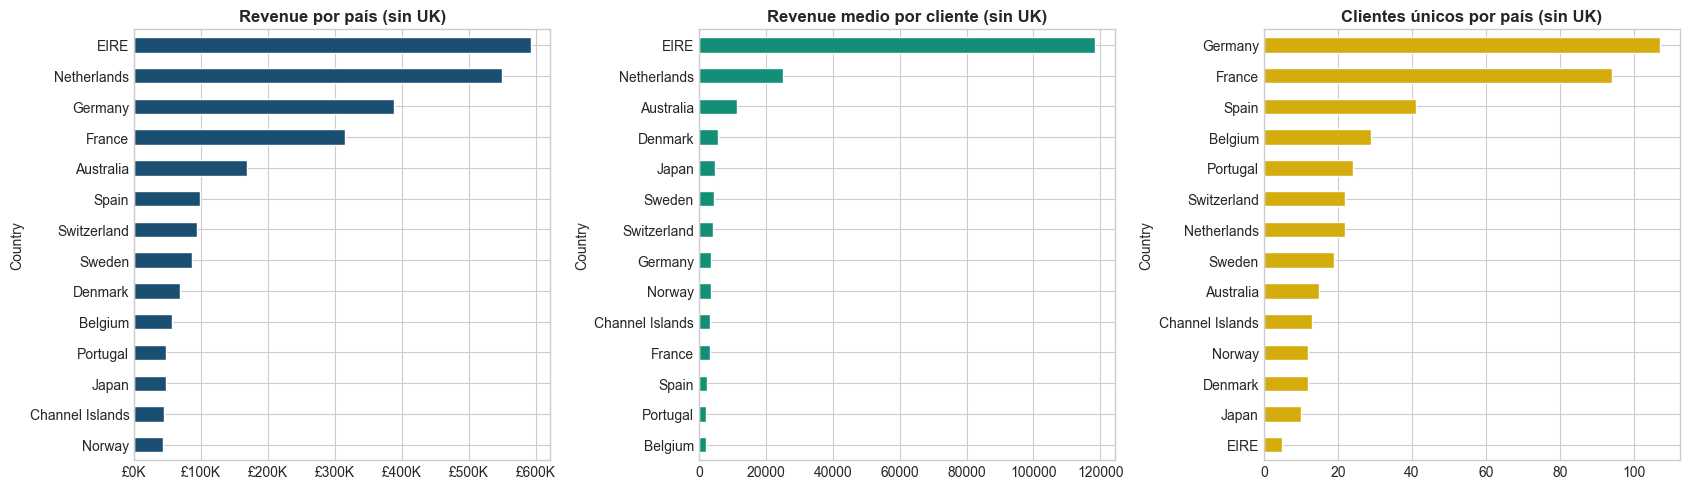


UK representa el 83.8% del revenue total — mercado dominante
EIRE (Irlanda) es el segundo mercado con 3.4% del revenue


In [14]:
geo = df.groupby('Country').agg(
    Revenue      = ('Revenue',      'sum'),
    Clientes     = ('Customer ID',  'nunique'),
    Facturas     = ('Invoice',      'nunique'),
    TicketMedio  = ('Revenue',      'mean'),
    PrecioMedio  = ('Price',        'mean'),
).sort_values('Revenue', ascending=False)

geo['Revenue_pct']     = geo['Revenue']  / geo['Revenue'].sum()  * 100
geo['Rev_por_cliente'] = geo['Revenue']  / geo['Clientes']

print('=== TOP 15 países por Revenue ===')
print(geo.head(15).to_string())

geo_no_uk = geo[geo.index != 'United Kingdom'].head(14)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

geo_no_uk.sort_values('Revenue')['Revenue'].plot(
    kind='barh', ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Revenue por país (sin UK)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}K'))

geo_no_uk.sort_values('Rev_por_cliente')['Rev_por_cliente'].plot(
    kind='barh', ax=axes[1], color=PALETTE[1], edgecolor='white')
axes[1].set_title('Revenue medio por cliente (sin UK)', fontweight='bold')

geo_no_uk.sort_values('Clientes')['Clientes'].plot(
    kind='barh', ax=axes[2], color=PALETTE[2], edgecolor='white')
axes[2].set_title('Clientes únicos por país (sin UK)', fontweight='bold')

plt.tight_layout(); plt.show()

uk_pct = geo.loc['United Kingdom','Revenue_pct']
print(f'\nUK representa el {uk_pct:.1f}% del revenue total — mercado dominante')
print(f'EIRE (Irlanda) es el segundo mercado con {geo.loc["EIRE","Revenue_pct"]:.1f}% del revenue')

### 4.3 Análisis de producto — Pareto y concentración

=== TOP 10 productos por Revenue ===
                                                  Revenue  Unidades  Clientes  Facturas
StockCode Description                                                                  
22423     REGENCY CAKESTAND 3 TIER           285,992.3500     24858      1314      3317
85123A    WHITE HANGING HEART T-LIGHT HOLDER 251,731.2600     93520      1490      4888
23843     PAPER CRAFT , LITTLE BIRDIE        168,469.6000     80995         1         1
85099B    JUMBO BAG RED RETROSPOT            136,684.7900     75597       860      2612
84879     ASSORTED COLOUR BIRD ORNAMENT      126,704.0600     79694      1010      2652
47566     PARTY BUNTING                      103,802.5300     23591       894      2077
23166     MEDIUM CERAMIC TOP STORAGE JAR      81,416.7300     77916       138       195
22086     PAPER CHAIN KIT 50'S CHRISTMAS      79,455.6800     29430       896      1691
79321     CHILLI LIGHTS                       72,527.7900     15658       304      

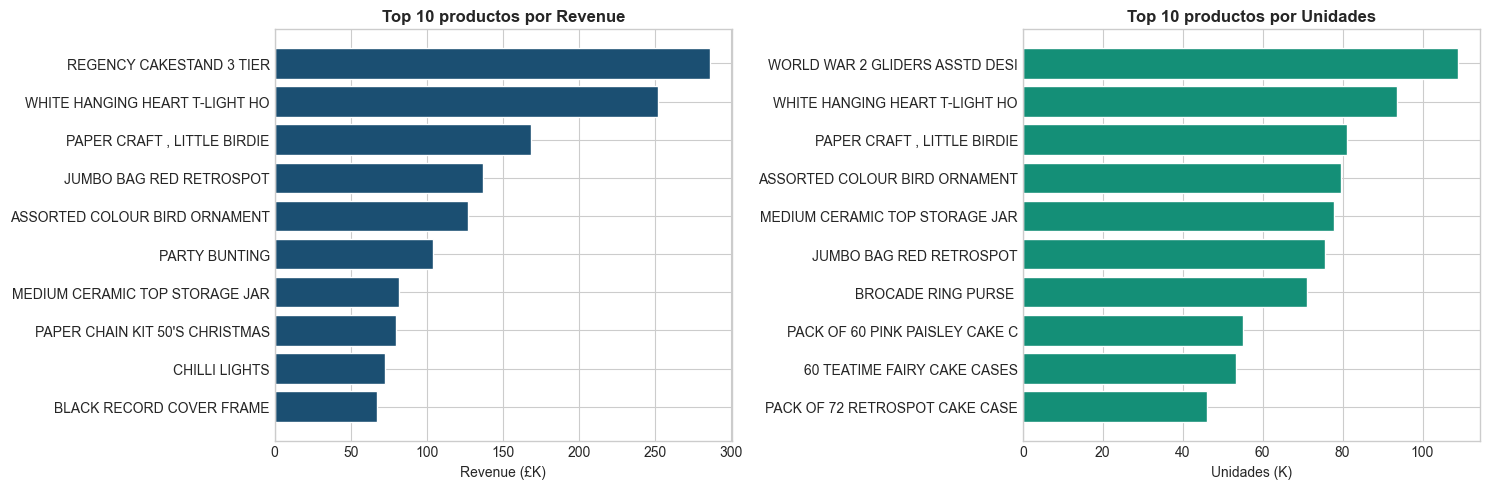

In [15]:
prod = df.groupby(['StockCode','Description']).agg(
    Revenue  = ('Revenue',      'sum'),
    Unidades = ('Quantity',     'sum'),
    Clientes = ('Customer ID',  'nunique'),
    Facturas = ('Invoice',      'nunique'),
).sort_values('Revenue', ascending=False)

print('=== TOP 10 productos por Revenue ===')
print(prod.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top10_rev  = prod.head(10)
top10_uni  = prod.sort_values('Unidades', ascending=False).head(10)
labels_rev = [d[:30] for d in top10_rev.index.get_level_values('Description')]
labels_uni = [d[:30] for d in top10_uni.index.get_level_values('Description')]

axes[0].barh(labels_rev[::-1], top10_rev['Revenue'].values[::-1]/1000, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Top 10 productos por Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (£K)')

axes[1].barh(labels_uni[::-1], top10_uni['Unidades'].values[::-1]/1000, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Top 10 productos por Unidades', fontweight='bold')
axes[1].set_xlabel('Unidades (K)')

plt.tight_layout(); plt.show()

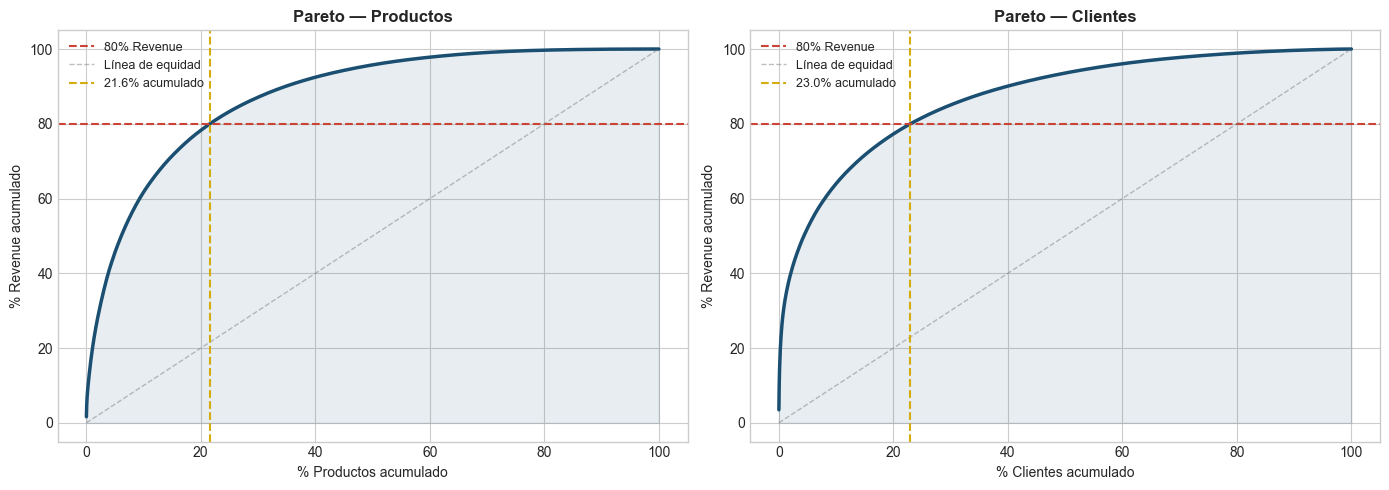

Pareto Productos: el 21.6% de productos genera el 80% del revenue
Pareto Clientes:  el 23.0%  de clientes genera el 80% del revenue


In [16]:
# Curva de Pareto — Productos
prod_sorted = prod.sort_values('Revenue', ascending=False).reset_index()
prod_sorted['rev_cum_pct']  = prod_sorted['Revenue'].cumsum() / prod_sorted['Revenue'].sum() * 100
prod_sorted['prod_cum_pct'] = (prod_sorted.index + 1) / len(prod_sorted) * 100

# Curva de Pareto — Clientes
cli_sorted = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).reset_index()
cli_sorted['rev_cum_pct']  = cli_sorted['Revenue'].cumsum() / cli_sorted['Revenue'].sum() * 100
cli_sorted['cli_cum_pct']  = (cli_sorted.index + 1) / len(cli_sorted) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_p, xcol, xlabel, title in [
    (axes[0], prod_sorted, 'prod_cum_pct', '% Productos acumulado', 'Pareto — Productos'),
    (axes[1], cli_sorted,  'cli_cum_pct',  '% Clientes acumulado',  'Pareto — Clientes'),
]:
    ax.plot(df_p[xcol], df_p['rev_cum_pct'], color=PALETTE[0], lw=2.5)
    ax.fill_between(df_p[xcol], df_p['rev_cum_pct'], alpha=0.1, color=PALETTE[0])
    ax.axhline(80, color=PALETTE[3], ls='--', lw=1.5, label='80% Revenue')
    ax.plot([0,100],[0,100], 'gray', ls='--', lw=1, alpha=0.5, label='Línea de equidad')
    idx80 = (df_p['rev_cum_pct'] >= 80).idxmax()
    ax.axvline(df_p.loc[idx80, xcol], color=PALETTE[2], ls='--', lw=1.5,
               label=f'{df_p.loc[idx80,xcol]:.1f}% acumulado')
    ax.set_xlabel(xlabel); ax.set_ylabel('% Revenue acumulado')
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

idx80_p = (prod_sorted['rev_cum_pct'] >= 80).idxmax()
idx80_c = (cli_sorted['rev_cum_pct']  >= 80).idxmax()
print(f'Pareto Productos: el {prod_sorted.loc[idx80_p,"prod_cum_pct"]:.1f}% de productos genera el 80% del revenue')
print(f'Pareto Clientes:  el {cli_sorted.loc[idx80_c,"cli_cum_pct"]:.1f}%  de clientes genera el 80% del revenue')

### 4.4 Comportamiento de cliente — RFM descriptivo y distribuciones

=== Estadísticas RFM por cliente (dataset completo) ===
         Recency  Frequency     Monetary   AvgTicket
count 5,861.0000 5,861.0000   5,861.0000  5,861.0000
mean    199.9379     6.2496   2,965.5612    388.6192
std     209.2019    12.7748  14,592.5450  1,254.4680
min       0.0000     1.0000       2.9500      2.9500
25%      25.0000     1.0000     341.9000    178.3960
50%      95.0000     3.0000     874.2500    281.7600
75%     378.0000     7.0000   2,279.4900    416.6867
max     738.0000   376.0000 608,821.6500 84,236.2500


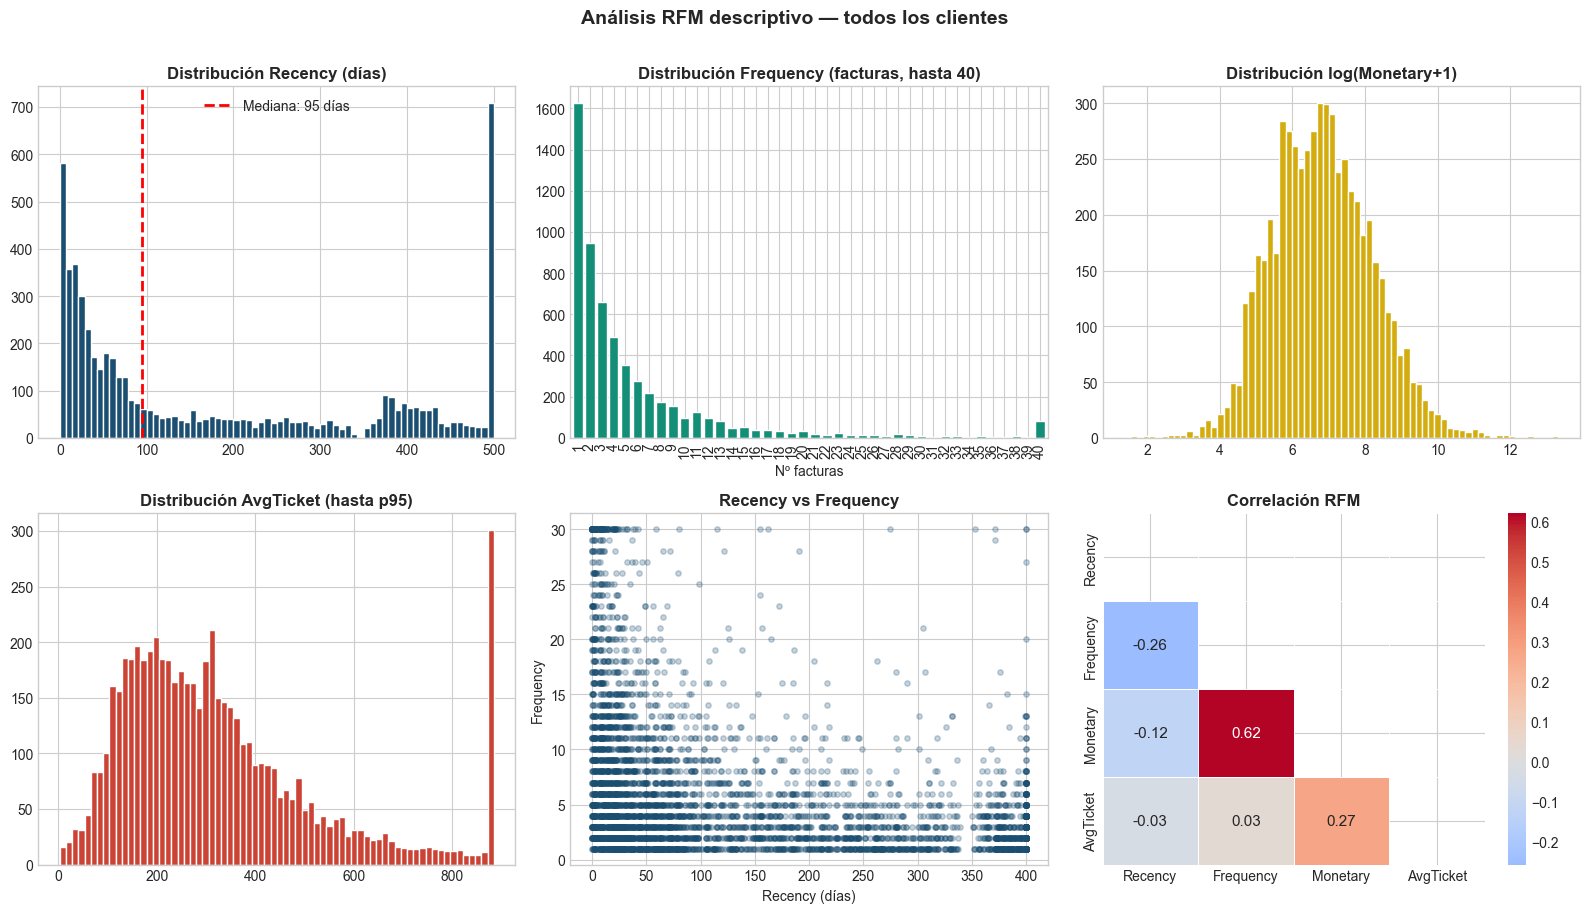

In [17]:
fecha_ref = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (fecha_ref - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('Revenue',     'sum'),
).reset_index()
rfm['AvgTicket'] = rfm['Monetary'] / rfm['Frequency']

print('=== Estadísticas RFM por cliente (dataset completo) ===')
print(rfm[['Recency','Frequency','Monetary','AvgTicket']].describe().to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Recency
rfm['Recency'].clip(upper=500).hist(bins=70, ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].axvline(rfm['Recency'].median(), color='red', ls='--', lw=2,
                label=f'Mediana: {rfm["Recency"].median():.0f} días')
axes[0].set_title('Distribución Recency (días)', fontweight='bold')
axes[0].legend()

# Frequency
rfm['Frequency'].clip(upper=40).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=PALETTE[1], edgecolor='white', width=0.8)
axes[1].set_title('Distribución Frequency (facturas, hasta 40)', fontweight='bold')
axes[1].set_xlabel('Nº facturas')

# Monetary log
np.log1p(rfm['Monetary']).hist(bins=70, ax=axes[2], color=PALETTE[2], edgecolor='white')
axes[2].set_title('Distribución log(Monetary+1)', fontweight='bold')

# AvgTicket
rfm['AvgTicket'].clip(upper=rfm['AvgTicket'].quantile(0.95)).hist(
    bins=70, ax=axes[3], color=PALETTE[3], edgecolor='white')
axes[3].set_title('Distribución AvgTicket (hasta p95)', fontweight='bold')

# Scatter Recency vs Frequency
axes[4].scatter(rfm['Recency'].clip(upper=400), rfm['Frequency'].clip(upper=30),
                alpha=0.25, color=PALETTE[0], s=15)
axes[4].set_xlabel('Recency (días)'); axes[4].set_ylabel('Frequency')
axes[4].set_title('Recency vs Frequency', fontweight='bold')

# Heatmap correlación
corr = rfm[['Recency','Frequency','Monetary','AvgTicket']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=axes[5], linewidths=0.5, annot_kws={'size': 11})
axes[5].set_title('Correlación RFM', fontweight='bold')

plt.suptitle('Análisis RFM descriptivo — todos los clientes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 4.5 Análisis de cohortes — Retención mes a mes

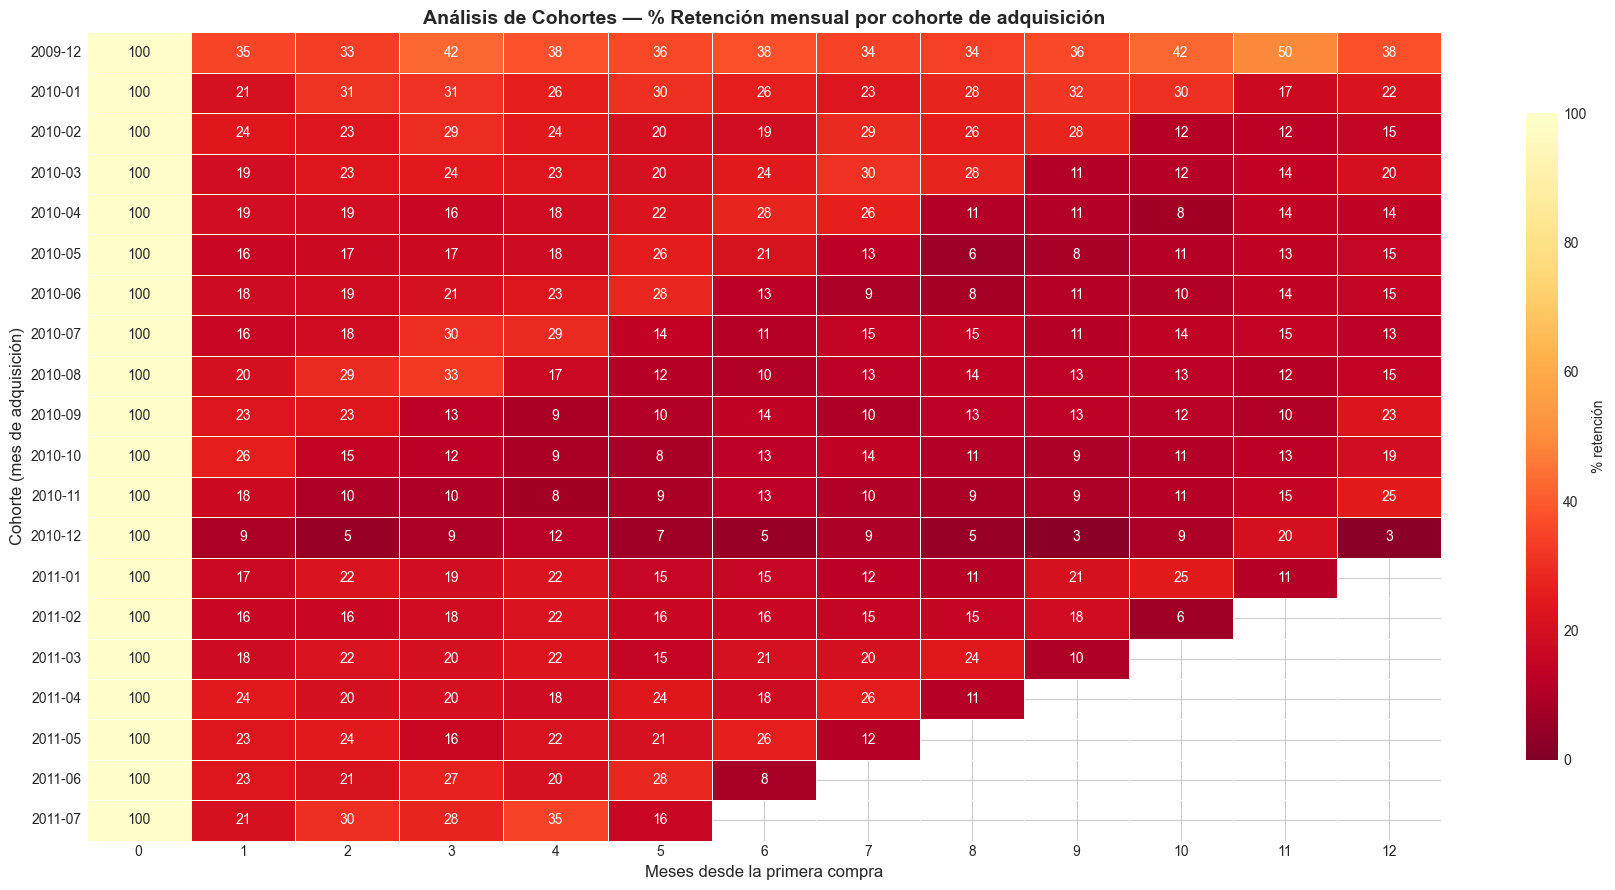

Retención media (%) por mes posterior a la primera compra:
  Mes  0: 100.0%
  Mes  1: 21.0%
  Mes  2: 21.9%
  Mes  3: 21.7%
  Mes  4: 20.6%
  Mes  5: 18.9%
  Mes  6: 17.9%
  Mes  7: 17.8%
  Mes  8: 15.7%
  Mes  9: 15.3%
  Mes 10: 15.0%
  Mes 11: 16.4%
  Mes 12: 18.2%


In [19]:
df['CohortMonth'] = (
    df.groupby('Customer ID')['InvoiceDate']
    .transform('min')
    .dt.to_period('M')
)
df['OrderMonth']  = df['InvoiceDate'].dt.to_period('M')
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

cohort_data  = df.groupby(['CohortMonth','CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
cohort_size  = cohort_pivot.iloc[:, 0]
retention    = (cohort_pivot.divide(cohort_size, axis=0) * 100).round(1)

fig, ax = plt.subplots(figsize=(18, 9))
ret_show = retention.iloc[:, :13].head(20)
sns.heatmap(
    ret_show, annot=True, fmt='.0f', cmap='YlOrRd_r',
    linewidths=0.4, ax=ax, vmin=0, vmax=100,
    cbar_kws={'label': '% retención', 'shrink': 0.8}
)
ax.set_title('Análisis de Cohortes — % Retención mensual por cohorte de adquisición',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Meses desde la primera compra', fontsize=12)
ax.set_ylabel('Cohorte (mes de adquisición)', fontsize=12)
plt.tight_layout(); plt.show()

ret_media = retention.mean().head(13)
print('Retención media (%) por mes posterior a la primera compra:')
for mes, val in ret_media.items():
    print(f'  Mes {mes:2d}: {val:.1f}%')

---
## 5. Feature Engineering — Variables predictoras (14 features)

**Estrategia temporal:**
- **Ventana de observación:** todo el período anterior al cutoff → construimos las features
- **Ventana de predicción:** período posterior al cutoff → etiquetamos si recompró (1) o no (0)
- El cutoff se fija a **12 meses antes** del final del dataset para maximizar datos de observación

In [20]:
fecha_max = df['InvoiceDate'].max()
cutoff    = fecha_max - pd.DateOffset(months=12)

print(f'Fecha máxima del dataset: {fecha_max.date()}')
print(f'Fecha de corte (cutoff):  {cutoff.date()}')

df_obs  = df[df['InvoiceDate'] < cutoff].copy()   # ventana de observación
df_pred = df[df['InvoiceDate'] >= cutoff].copy()  # ventana de predicción

print(f'\nVentana observación: {df_obs.shape[0]:,} filas | {df_obs["Customer ID"].nunique():,} clientes')
print(f'Ventana predicción:  {df_pred.shape[0]:,} filas | {df_pred["Customer ID"].nunique():,} clientes')

Fecha máxima del dataset: 2011-12-09
Fecha de corte (cutoff):  2010-12-09

Ventana observación: 411,430 filas | 4,294 clientes
Ventana predicción:  379,309 filas | 4,266 clientes


In [21]:
# ─── Agrupaciones auxiliares ──────────────────────────────────────────────
ref          = cutoff
ultima       = df_obs.groupby('Customer ID')['InvoiceDate'].max()
primera      = df_obs.groupby('Customer ID')['InvoiceDate'].min()
tickets      = df_obs.groupby(['Customer ID','Invoice'])['Revenue'].sum()
cutoff6      = cutoff - pd.DateOffset(months=6)

feat = pd.DataFrame(index=df_obs['Customer ID'].unique())
feat.index.name = 'Customer ID'

# ── RFM clásico ───────────────────────────────────────────────────────────
feat['recency_days']     = (ref - ultima).dt.days
feat['frequency']        = df_obs.groupby('Customer ID')['Invoice'].nunique()
feat['total_revenue']    = df_obs.groupby('Customer ID')['Revenue'].sum()

# ── Estadísticas de ticket ────────────────────────────────────────────────
feat['avg_ticket']       = tickets.groupby('Customer ID').mean()
feat['std_ticket']       = tickets.groupby('Customer ID').std().fillna(0)
feat['max_ticket']       = tickets.groupby('Customer ID').max()
feat['min_ticket']       = tickets.groupby('Customer ID').min()

# ── Variedad y profundidad de compra ─────────────────────────────────────
feat['unique_products']  = df_obs.groupby('Customer ID')['StockCode'].nunique()
feat['total_items']      = df_obs.groupby('Customer ID')['Quantity'].sum()
feat['avg_qty_per_line'] = df_obs.groupby('Customer ID')['Quantity'].mean()
feat['avg_price']        = df_obs.groupby('Customer ID')['Price'].mean()

# ── Dimensión temporal del cliente ───────────────────────────────────────
feat['active_days']      = (ultima - primera).dt.days
feat['purchase_rate']    = feat['frequency'] / (feat['active_days'] + 1)   # facturas/día

# ── Geografía ─────────────────────────────────────────────────────────────
pais_cliente = df_obs.groupby('Customer ID')['Country'].first()
feat['is_uk']            = (pais_cliente == 'United Kingdom').astype(int)

# ── Estacionalidad ────────────────────────────────────────────────────────
feat['month_last_buy']   = ultima.dt.month
feat['q4_buyer']         = (
    df_obs[df_obs['Month'].isin([10,11,12])]
    .groupby('Customer ID')['Invoice'].nunique().gt(0).astype(int)
)

# ── Tendencia: revenue últimos 6 meses vs anteriores ─────────────────────
rev_rec = df_obs[df_obs['InvoiceDate'] >= cutoff6].groupby('Customer ID')['Revenue'].sum()
rev_ant = df_obs[df_obs['InvoiceDate'] <  cutoff6].groupby('Customer ID')['Revenue'].sum()
feat['rev_trend']        = (rev_rec / (rev_ant + 1)).clip(0, 20).fillna(0)

feat = feat.reset_index().fillna(0)

FEAT_COLS = [
    'recency_days','frequency','total_revenue','avg_ticket','std_ticket',
    'max_ticket','min_ticket','unique_products','total_items','avg_qty_per_line',
    'avg_price','active_days','purchase_rate','is_uk','month_last_buy',
    'q4_buyer','rev_trend'
]

print(f'Features construidas: {len(FEAT_COLS)} variables')
print(f'Clientes en el dataset de features: {len(feat):,}')
feat[FEAT_COLS].describe().T[['mean','std','min','50%','max']]

Features construidas: 17 variables
Clientes en el dataset de features: 4,294


,mean,std,min,50%,max
recency_days,90.0664,96.7271,0.0000,51.0000,373.0000
frequency,4.4122,7.9476,1.0000,2.0000,186.0000
total_revenue,"2,076.8663","9,144.5639",1.5500,711.4650,"373,170.4800"
avg_ticket,383.2468,488.1039,1.5500,293.7750,"11,880.8400"
std_ticket,149.2713,385.4885,0.0000,70.1818,"11,456.1162"
max_ticket,626.4738,"1,372.0545",1.5500,379.6500,"44,051.6000"
min_ticket,238.4610,404.3901,0.8400,162.9100,"11,880.8400"
unique_products,63.6542,85.5945,1.0000,38.0000,"1,738.0000"
total_items,"1,317.2513","6,562.5886",1.0000,395.5000,"220,596.0000"
avg_qty_per_line,21.7517,115.9200,1.0000,9.4794,"4,460.2941"


Clientes totales:    4,294
Recompraron (1):     2,699  (62.9%)
No recompraron (0):  1,595  (37.1%)


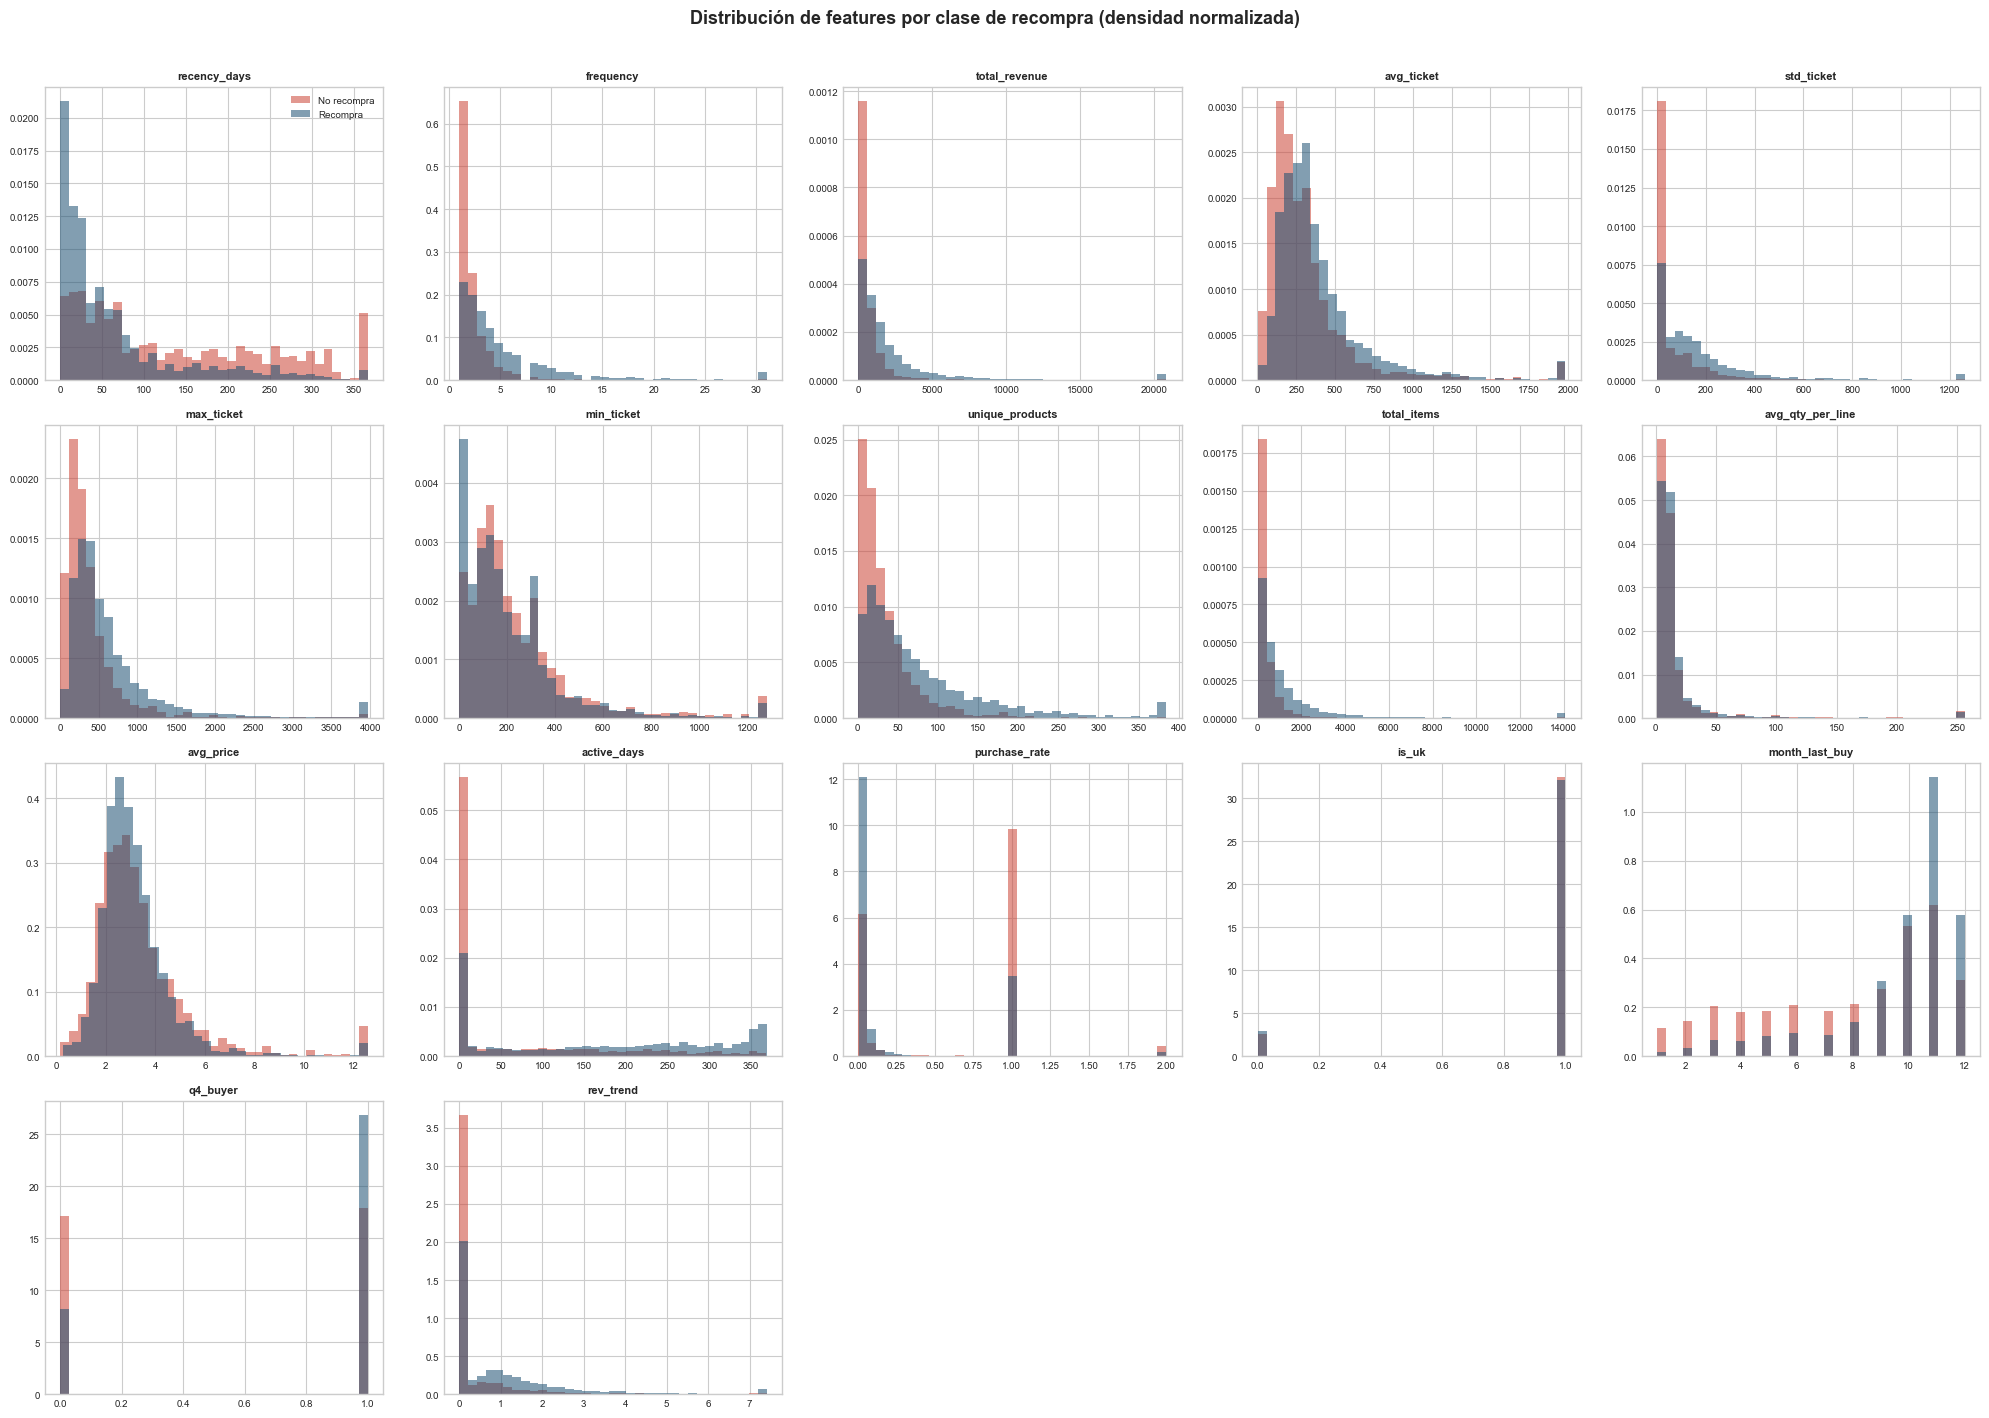

In [22]:
# ─── Variable objetivo ────────────────────────────────────────────────────
clientes_que_recompran = set(df_pred['Customer ID'].unique())
feat['target'] = feat['Customer ID'].isin(clientes_que_recompran).astype(int)

tasa_pos = feat['target'].mean()
print(f'Clientes totales:    {len(feat):,}')
print(f'Recompraron (1):     {feat["target"].sum():,}  ({tasa_pos:.1%})')
print(f'No recompraron (0):  {(feat["target"]==0).sum():,}  ({1-tasa_pos:.1%})')

# Distribución de cada feature por clase
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(FEAT_COLS):
    p99 = feat[col].quantile(0.99)
    for cls, color, lbl in [(0, PALETTE[3], 'No recompra'), (1, PALETTE[0], 'Recompra')]:
        vals = feat[feat['target']==cls][col].clip(upper=p99)
        axes[i].hist(vals, bins=35, alpha=0.55, color=color, label=lbl, density=True)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    if i == 0: axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de features por clase de recompra (densidad normalizada)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 6. Preparación del dataset de modelado

In [23]:
X = feat[FEAT_COLS].copy()
y = feat['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Escalado para modelos lineales/distancia
scaler = RobustScaler()   # más resistente a outliers que StandardScaler
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Proporción positivos — Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}')
print(f'Nº features: {X.shape[1]}')

Train: 3,435  |  Test: 859
Proporción positivos — Train: 62.85%  |  Test: 62.86%
Nº features: 17


---
## 7. Benchmark de 7 algoritmos base

Evaluamos todos los algoritmos en configuración por defecto para tener una línea de base objetiva antes de optimizar.

Logistic Regression       → AUC: 0.7677 ± 0.0122
AdaBoost                  → AUC: 0.7723 ± 0.0142
Extra Trees               → AUC: 0.7644 ± 0.0225
Random Forest             → AUC: 0.7644 ± 0.0182
Gradient Boosting         → AUC: 0.7804 ± 0.0152
XGBoost                   → AUC: 0.7534 ± 0.0148
LightGBM                  → AUC: 0.7639 ± 0.0148
CatBoost                  → AUC: 0.7786 ± 0.0114


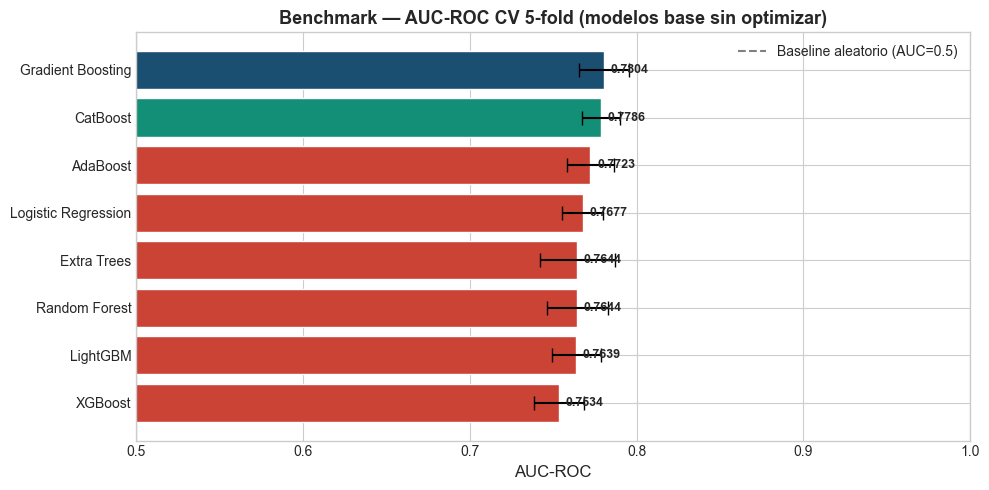

In [24]:
modelos_base = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=SEED, C=1.0), True),
    'AdaBoost':            (AdaBoostClassifier(n_estimators=100, random_state=SEED), False),
    'Extra Trees':         (ExtraTreesClassifier(n_estimators=100, random_state=SEED, n_jobs=-1), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, random_state=SEED), False),
    'XGBoost':             (XGBClassifier(eval_metric='logloss', random_state=SEED, verbosity=0), False),
    'LightGBM':            (LGBMClassifier(random_state=SEED, verbosity=-1), False),
}

if HAS_CATBOOST:
    modelos_base['CatBoost'] = (CatBoostClassifier(random_state=SEED, verbose=0), False)

resultados_base = {}
for nombre, (modelo, scaled) in modelos_base.items():
    X_cv = X_train_sc if scaled else X_train
    scores = cross_val_score(modelo, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    resultados_base[nombre] = {
        'AUC_mean': scores.mean(),
        'AUC_std':  scores.std(),
        'AUC_min':  scores.min(),
        'AUC_max':  scores.max(),
    }
    print(f'{nombre:25s} → AUC: {scores.mean():.4f} ± {scores.std():.4f}')

res_df = pd.DataFrame(resultados_base).T.sort_values('AUC_mean')

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[3] if n != res_df.index[-1] and n != res_df.index[-2]
          else (PALETTE[0] if n == res_df.index[-1] else PALETTE[1])
          for n in res_df.index]
bars = ax.barh(res_df.index, res_df['AUC_mean'],
               xerr=res_df['AUC_std'], color=colors, capsize=5, edgecolor='white')
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='Baseline aleatorio (AUC=0.5)')
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('AUC-ROC', fontsize=12)
ax.set_title('Benchmark — AUC-ROC CV 5-fold (modelos base sin optimizar)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
for i, (idx, row) in enumerate(res_df.iterrows()):
    ax.text(row['AUC_mean'] + 0.004, i, f'{row["AUC_mean"]:.4f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Optimización de hiperparámetros con Optuna

Optimizamos los 3 mejores candidatos. Optuna usa búsqueda bayesiana con el estimador TPE (Tree-structured Parzen Estimator), **mucho más eficiente** que GridSearch o RandomSearch.

In [25]:
N_TRIALS = 60   # Aumentar a 100+ para producción

# ── XGBoost ───────────────────────────────────────────────────────────────
def obj_xgb(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators',      100, 900),
        max_depth         = trial.suggest_int('max_depth',          2,  9),
        learning_rate     = trial.suggest_float('learning_rate',  0.003, 0.3, log=True),
        subsample         = trial.suggest_float('subsample',        0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha',      1e-5, 10,  log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',     1e-5, 10,  log=True),
        min_child_weight  = trial.suggest_int('min_child_weight',   1,  10),
        gamma             = trial.suggest_float('gamma',            0,   1.0),
        eval_metric='logloss', random_state=SEED, verbosity=0
    )
    return cross_val_score(XGBClassifier(**p), X_train, y_train,
                           cv=cv, scoring='roc_auc', n_jobs=-1).mean()

# ── LightGBM ──────────────────────────────────────────────────────────────
def obj_lgbm(trial):
    p = dict(
        n_estimators       = trial.suggest_int('n_estimators',      100, 900),
        max_depth          = trial.suggest_int('max_depth',          2,  12),
        learning_rate      = trial.suggest_float('learning_rate',  0.003, 0.3, log=True),
        num_leaves         = trial.suggest_int('num_leaves',        15, 200),
        subsample          = trial.suggest_float('subsample',        0.5, 1.0),
        colsample_bytree   = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha          = trial.suggest_float('reg_alpha',      1e-5, 10,  log=True),
        reg_lambda         = trial.suggest_float('reg_lambda',     1e-5, 10,  log=True),
        min_child_samples  = trial.suggest_int('min_child_samples',  5,  60),
        random_state=SEED, verbosity=-1
    )
    return cross_val_score(LGBMClassifier(**p), X_train, y_train,
                           cv=cv, scoring='roc_auc', n_jobs=-1).mean()

# ── Random Forest ─────────────────────────────────────────────────────────
def obj_rf(trial):
    p = dict(
        n_estimators       = trial.suggest_int('n_estimators',     100, 600),
        max_depth          = trial.suggest_int('max_depth',          3,  25),
        min_samples_split  = trial.suggest_int('min_samples_split',  2,  20),
        min_samples_leaf   = trial.suggest_int('min_samples_leaf',   1,  10),
        max_features       = trial.suggest_categorical('max_features', ['sqrt','log2',None]),
        random_state=SEED, n_jobs=-1
    )
    return cross_val_score(RandomForestClassifier(**p), X_train, y_train,
                           cv=cv, scoring='roc_auc', n_jobs=-1).mean()

studies = {}
objectives = {'XGBoost': obj_xgb, 'LightGBM': obj_lgbm, 'RandomForest': obj_rf}

for name, obj in objectives.items():
    study = optuna.create_study(direction='maximize', study_name=name,
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=N_TRIALS, show_progress_bar=True)
    studies[name] = study
    print(f'\n{name}: mejor AUC-CV = {study.best_value:.5f}')
    print(f'  Parámetros: {study.best_params}')

Best trial: 18. Best value: 0.78572: 100%|██████████| 60/60 [01:26<00:00,  1.43s/it]



XGBoost: mejor AUC-CV = 0.78572
  Parámetros: {'n_estimators': 684, 'max_depth': 3, 'learning_rate': 0.005655981027342374, 'subsample': 0.5003943379120007, 'colsample_bytree': 0.6571436469988812, 'reg_alpha': 0.7981727858307018, 'reg_lambda': 1.877412444132651, 'min_child_weight': 7, 'gamma': 0.5150858721263606}


Best trial: 28. Best value: 0.785879: 100%|██████████| 60/60 [03:35<00:00,  3.60s/it]



LightGBM: mejor AUC-CV = 0.78588
  Parámetros: {'n_estimators': 516, 'max_depth': 4, 'learning_rate': 0.006732091729270073, 'num_leaves': 47, 'subsample': 0.9596844931220331, 'colsample_bytree': 0.6368503463570148, 'reg_alpha': 0.021067599503217425, 'reg_lambda': 7.40791394351047, 'min_child_samples': 9}


Best trial: 31. Best value: 0.784445: 100%|██████████| 60/60 [05:10<00:00,  5.18s/it]


RandomForest: mejor AUC-CV = 0.78445
  Parámetros: {'n_estimators': 466, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'sqrt'}


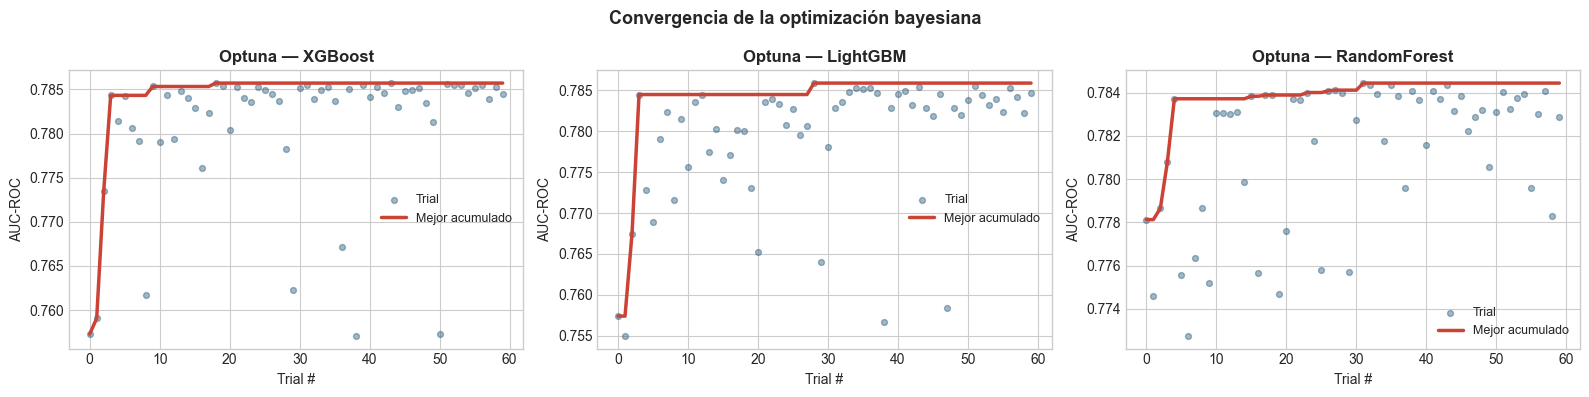


=== Comparativa final — CV vs. base ===
XGBoost             : base=0.7534 → optuna=0.7857  (Δ=+0.0323)
LightGBM            : base=0.7639 → optuna=0.7859  (Δ=+0.0220)
RandomForest        : base=0.7644 → optuna=0.7844  (Δ=+0.0200)


In [26]:
# Historial de optimización
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, study) in zip(axes, studies.items()):
    t_df = study.trials_dataframe()
    ax.scatter(t_df.index, t_df['value'], alpha=0.4, color=PALETTE[0], s=18, label='Trial')
    ax.plot(t_df['value'].cummax(), color=PALETTE[3], lw=2.5, label='Mejor acumulado')
    ax.set_title(f'Optuna — {name}', fontweight='bold')
    ax.set_xlabel('Trial #'); ax.set_ylabel('AUC-ROC')
    ax.legend(fontsize=9)
plt.suptitle('Convergencia de la optimización bayesiana', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Comparativa final
print('\n=== Comparativa final — CV vs. base ===')
for name, study in studies.items():
    base = resultados_base.get(name, resultados_base.get(
        name.replace('Forest','Forest').replace('RandomForest','Random Forest'), {'AUC_mean': 0}))
    mejora = study.best_value - base.get('AUC_mean', 0)
    print(f'{name:20s}: base={base.get("AUC_mean",0):.4f} → optuna={study.best_value:.4f}  (Δ={mejora:+.4f})')

In [27]:
# ─── Construir el modelo ganador ──────────────────────────────────────────
best_study_name = max(studies, key=lambda k: studies[k].best_value)
best_params     = dict(studies[best_study_name].best_params)
print(f'Modelo ganador: {best_study_name}  (AUC-CV = {studies[best_study_name].best_value:.5f})')

if best_study_name == 'XGBoost':
    best_params.update({'eval_metric':'logloss','random_state':SEED,'verbosity':0})
    best_model = XGBClassifier(**best_params)
elif best_study_name == 'LightGBM':
    best_params.update({'random_state':SEED,'verbosity':-1})
    best_model = LGBMClassifier(**best_params)
else:
    best_params.update({'random_state':SEED,'n_jobs':-1})
    best_model = RandomForestClassifier(**best_params)

best_model.fit(X_train, y_train)
print('✓ Modelo entrenado en train completo')

Modelo ganador: LightGBM  (AUC-CV = 0.78588)
✓ Modelo entrenado en train completo


---
## 9. Evaluación completa del modelo final

In [28]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc_roc = roc_auc_score(y_test, y_prob)
ap      = average_precision_score(y_test, y_prob)
brier   = brier_score_loss(y_test, y_prob)
f1      = f1_score(y_test, y_pred)

print(f'=======================================================')
print(f'  Evaluación en Test — {best_study_name} optimizado')
print(f'=======================================================')
print(f'  AUC-ROC:            {auc_roc:.5f}')
print(f'  Average Precision:  {ap:.5f}')
print(f'  Brier Score:        {brier:.5f}  (↓ mejor, baseline≈{y_test.mean()*(1-y_test.mean()):.3f})')
print(f'  F1-Score (thr=0.5): {f1:.5f}')
print()
print(classification_report(y_test, y_pred, target_names=['No recompra','Recompra'], digits=4))

  Evaluación en Test — LightGBM optimizado
  AUC-ROC:            0.81238
  Average Precision:  0.88322
  Brier Score:        0.17021  (↓ mejor, baseline≈0.233)
  F1-Score (thr=0.5): 0.80210

              precision    recall  f1-score   support

 No recompra     0.6809    0.5486    0.6076       319
    Recompra     0.7608    0.8481    0.8021       540

    accuracy                         0.7369       859
   macro avg     0.7209    0.6984    0.7049       859
weighted avg     0.7311    0.7369    0.7299       859



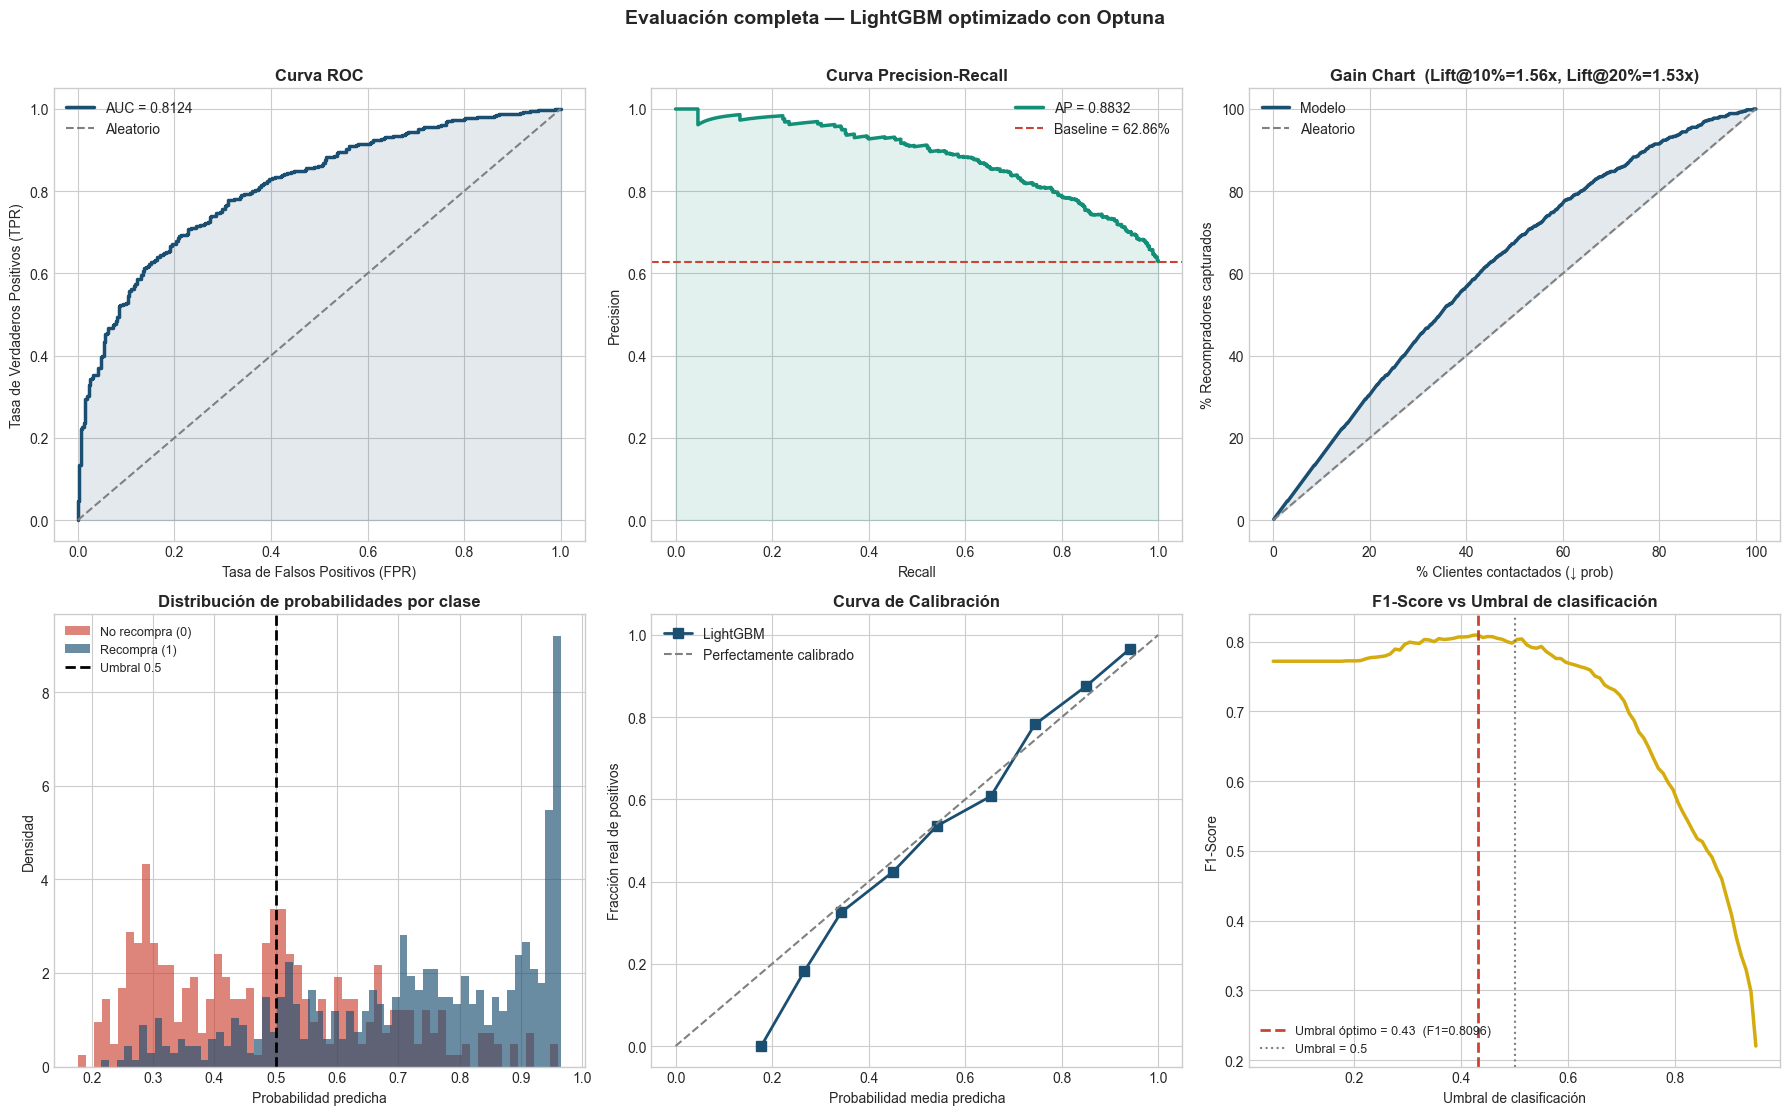

Lift top 10%: 1.56x  |  Lift top 20%: 1.53x
Umbral óptimo F1: 0.43


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0,0].plot(fpr, tpr, lw=2.5, color=PALETTE[0], label=f'AUC = {auc_roc:.4f}')
axes[0,0].fill_between(fpr, tpr, alpha=0.12, color=PALETTE[0])
axes[0,0].plot([0,1],[0,1],'--', color='gray', lw=1.5, label='Aleatorio')
axes[0,0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0,0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0,0].set_title('Curva ROC', fontweight='bold')
axes[0,0].legend(fontsize=10)

# 2. Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[0,1].plot(rec, prec, lw=2.5, color=PALETTE[1], label=f'AP = {ap:.4f}')
axes[0,1].fill_between(rec, prec, alpha=0.12, color=PALETTE[1])
axes[0,1].axhline(y_test.mean(), color=PALETTE[3], ls='--', lw=1.5,
                  label=f'Baseline = {y_test.mean():.2%}')
axes[0,1].set_xlabel('Recall'); axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Curva Precision-Recall', fontweight='bold')
axes[0,1].legend(fontsize=10)

# 3. Curva de Ganancia (Gain Chart)
res = pd.DataFrame({'prob':y_prob,'real':y_test.values}).sort_values('prob',ascending=False).reset_index(drop=True)
res['cum_gain']  = res['real'].cumsum() / res['real'].sum()
res['pop_pct']   = (res.index+1) / len(res)
axes[0,2].plot(res['pop_pct']*100, res['cum_gain']*100, lw=2.5, color=PALETTE[0], label='Modelo')
axes[0,2].plot([0,100],[0,100],'--',color='gray',lw=1.5,label='Aleatorio')
axes[0,2].fill_between(res['pop_pct']*100, res['cum_gain']*100, res['pop_pct']*100, alpha=0.12, color=PALETTE[0])
lift10 = res.loc[int(0.10*len(res)),'cum_gain'] / 0.10
lift20 = res.loc[int(0.20*len(res)),'cum_gain'] / 0.20
axes[0,2].set_xlabel('% Clientes contactados (↓ prob)'); axes[0,2].set_ylabel('% Recompradores capturados')
axes[0,2].set_title(f'Gain Chart  (Lift@10%={lift10:.2f}x, Lift@20%={lift20:.2f}x)', fontweight='bold')
axes[0,2].legend(fontsize=10)

# 4. Distribución de probabilidades
axes[1,0].hist(y_prob[y_test==0], bins=60, alpha=0.65, color=PALETTE[3], label='No recompra (0)', density=True)
axes[1,0].hist(y_prob[y_test==1], bins=60, alpha=0.65, color=PALETTE[0], label='Recompra (1)',    density=True)
axes[1,0].axvline(0.5, color='black', ls='--', lw=2, label='Umbral 0.5')
axes[1,0].set_xlabel('Probabilidad predicha'); axes[1,0].set_ylabel('Densidad')
axes[1,0].set_title('Distribución de probabilidades por clase', fontweight='bold')
axes[1,0].legend(fontsize=9)

# 5. Curva de calibración
prob_t, prob_p = calibration_curve(y_test, y_prob, n_bins=10)
axes[1,1].plot(prob_p, prob_t, 's-', lw=2, color=PALETTE[0], ms=7, label=best_study_name)
axes[1,1].plot([0,1],[0,1],'--',color='gray',lw=1.5,label='Perfectamente calibrado')
axes[1,1].set_xlabel('Probabilidad media predicha'); axes[1,1].set_ylabel('Fracción real de positivos')
axes[1,1].set_title('Curva de Calibración', fontweight='bold')
axes[1,1].legend(fontsize=10)

# 6. F1 vs umbral
umbrales = np.linspace(0.05, 0.95, 100)
f1s  = [f1_score(y_test, (y_prob>=u).astype(int), zero_division=0) for u in umbrales]
u_opt = umbrales[np.argmax(f1s)]
axes[1,2].plot(umbrales, f1s, lw=2.5, color=PALETTE[2])
axes[1,2].axvline(u_opt, color=PALETTE[3], ls='--', lw=2,
                  label=f'Umbral óptimo = {u_opt:.2f}  (F1={max(f1s):.4f})')
axes[1,2].axvline(0.5, color='gray', ls=':', lw=1.5, label='Umbral = 0.5')
axes[1,2].set_xlabel('Umbral de clasificación'); axes[1,2].set_ylabel('F1-Score')
axes[1,2].set_title('F1-Score vs Umbral de clasificación', fontweight='bold')
axes[1,2].legend(fontsize=9)

plt.suptitle(f'Evaluación completa — {best_study_name} optimizado con Optuna',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f'Lift top 10%: {lift10:.2f}x  |  Lift top 20%: {lift20:.2f}x')
print(f'Umbral óptimo F1: {u_opt:.2f}')

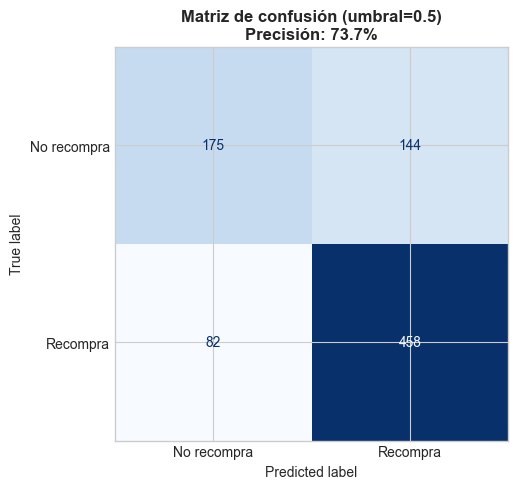

In [30]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No recompra','Recompra']).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Matriz de confusión (umbral=0.5)\n'
             f'Precisión: {cm.diagonal().sum()/cm.sum()*100:.1f}%', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 10. Explicabilidad SHAP

SHAP (SHapley Additive exPlanations) explica cada predicción individual y la importancia global de cada variable.

In [31]:
explainer  = shap.TreeExplainer(best_model)
shap_vals  = explainer.shap_values(X_test)
if isinstance(shap_vals, list): shap_vals = shap_vals[1]  # clase positiva en LGBM
print(f'SHAP values shape: {shap_vals.shape}  ✓')

SHAP values shape: (859, 17)  ✓


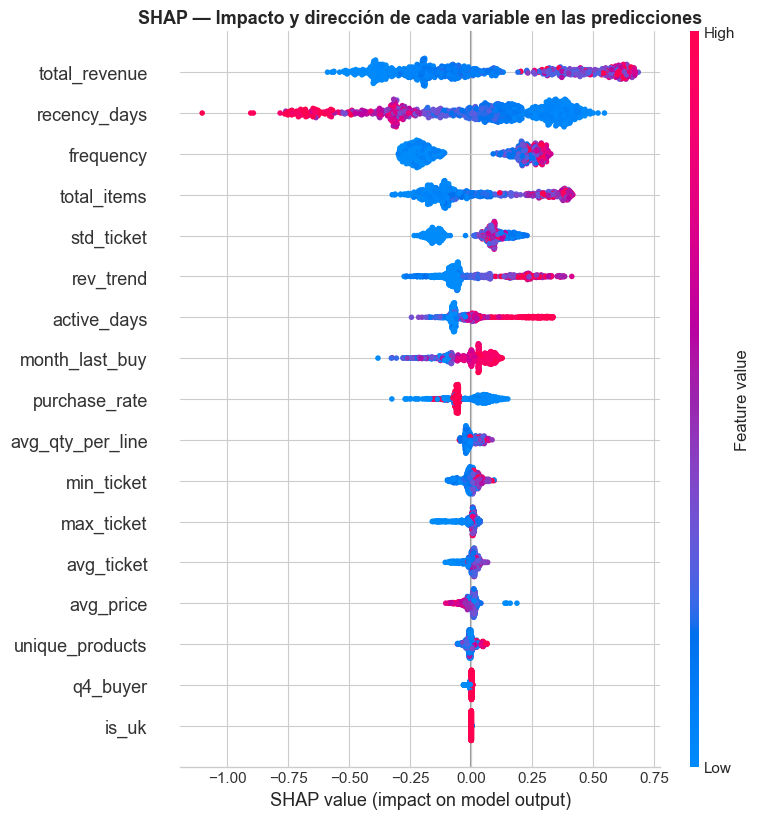

In [32]:
# Beeswarm plot — impacto global
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_vals, X_test, feature_names=FEAT_COLS, show=False, max_display=17)
plt.title('SHAP — Impacto y dirección de cada variable en las predicciones', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

=== Importancia global de variables (|SHAP| medio) ===
         feature  importance
   total_revenue      0.3170
    recency_days      0.2881
       frequency      0.2282
     total_items      0.1740
      std_ticket      0.1209
       rev_trend      0.1123
     active_days      0.0820
  month_last_buy      0.0694
   purchase_rate      0.0650
avg_qty_per_line      0.0230
      min_ticket      0.0216
      max_ticket      0.0190
      avg_ticket      0.0183
       avg_price      0.0179
 unique_products      0.0147
        q4_buyer      0.0035
           is_uk      0.0001


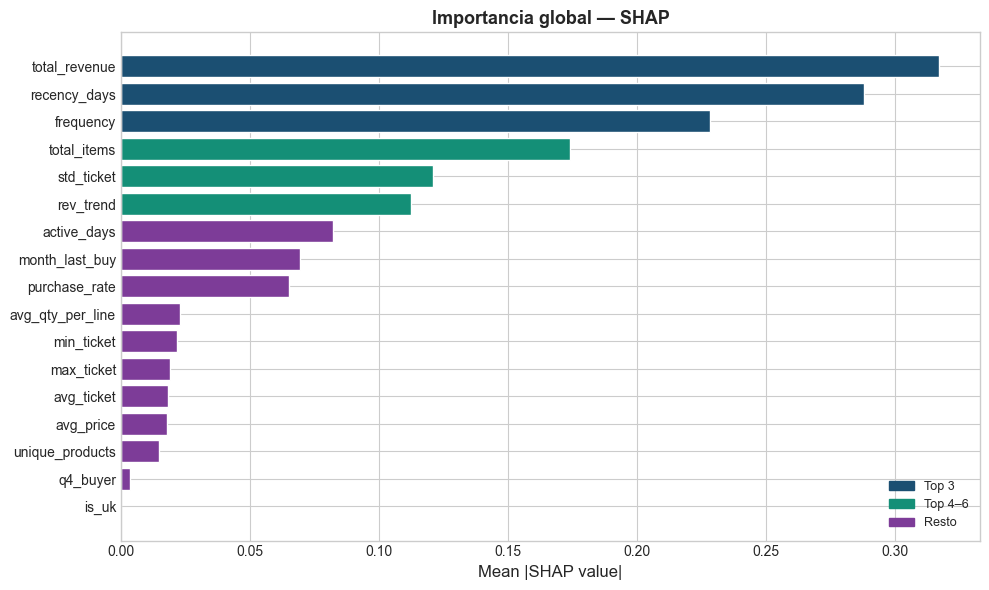

In [33]:
# Importancia media |SHAP|
shap_imp = pd.DataFrame({
    'feature':    FEAT_COLS,
    'importance': np.abs(shap_vals).mean(0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('=== Importancia global de variables (|SHAP| medio) ===')
print(shap_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE[0] if i < 3 else PALETTE[1] if i < 6 else PALETTE[4]
          for i in range(len(shap_imp))]
ax.barh(shap_imp['feature'][::-1], shap_imp['importance'][::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title('Importancia global — SHAP', fontweight='bold', fontsize=13)
patches = [
    mpatches.Patch(color=PALETTE[0], label='Top 3'),
    mpatches.Patch(color=PALETTE[1], label='Top 4–6'),
    mpatches.Patch(color=PALETTE[4], label='Resto'),
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout(); plt.show()

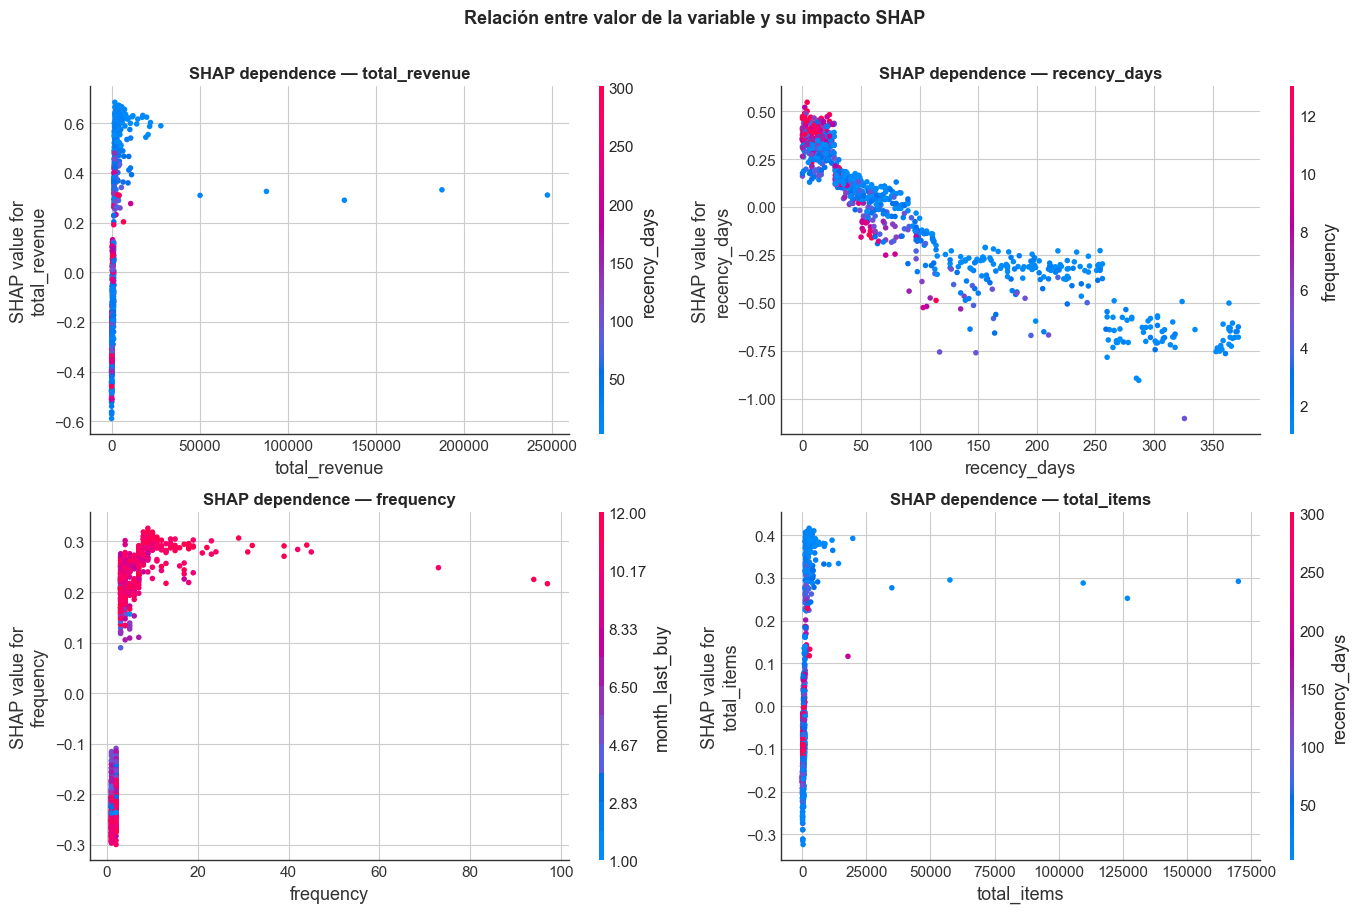

In [34]:
# Dependence plots — top 4 variables
top4 = shap_imp['feature'].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feat_name in zip(axes.flatten(), top4):
    shap.dependence_plot(feat_name, shap_vals, X_test,
                         feature_names=FEAT_COLS, ax=ax, show=False)
    ax.set_title(f'SHAP dependence — {feat_name}', fontweight='bold')
plt.suptitle('Relación entre valor de la variable y su impacto SHAP', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

Cliente con mayor prob.: índice 116 | prob = 0.9643 | real = 1


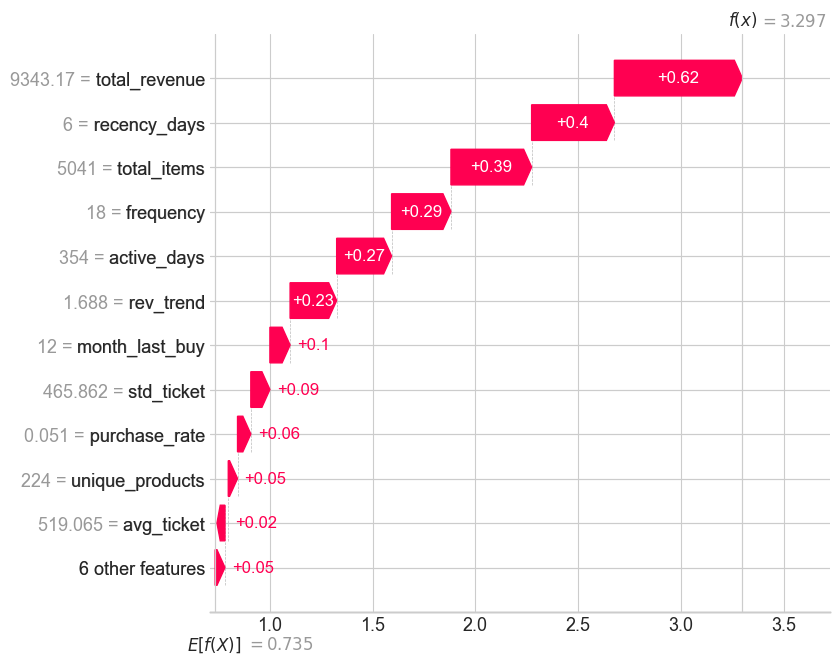

In [35]:
# Waterfall plot — cliente con mayor probabilidad predicha
base_val = explainer.expected_value
if isinstance(base_val, list): base_val = base_val[1]

idx_top = int(y_prob.argmax())
print(f'Cliente con mayor prob.: índice {idx_top} | prob = {y_prob[idx_top]:.4f} | real = {y_test.iloc[idx_top]}')

shap.waterfall_plot(
    shap.Explanation(
        values       = shap_vals[idx_top],
        base_values  = base_val,
        data         = X_test.iloc[idx_top].values,
        feature_names= FEAT_COLS
    ),
    max_display=12
)

---
## 11. Segmentación accionable y exportación

=== Distribución de segmentos ===
segmento
FIDELIZACION    2013
POTENCIAL       1731
RETENCION        550
Name: count, dtype: int64

=== Perfil medio por segmento ===
              recency_days  frequency  total_revenue  avg_ticket  unique_products  is_uk
segmento                                                                                
RETENCION         238.3000     1.1000       203.7000    179.6000          14.0000 0.9000
POTENCIAL         112.1000     1.9000       660.1000    364.9000          34.8000 0.9000
FIDELIZACION       30.6000     7.5000     3,806.9000    454.6000         102.1000 0.9000


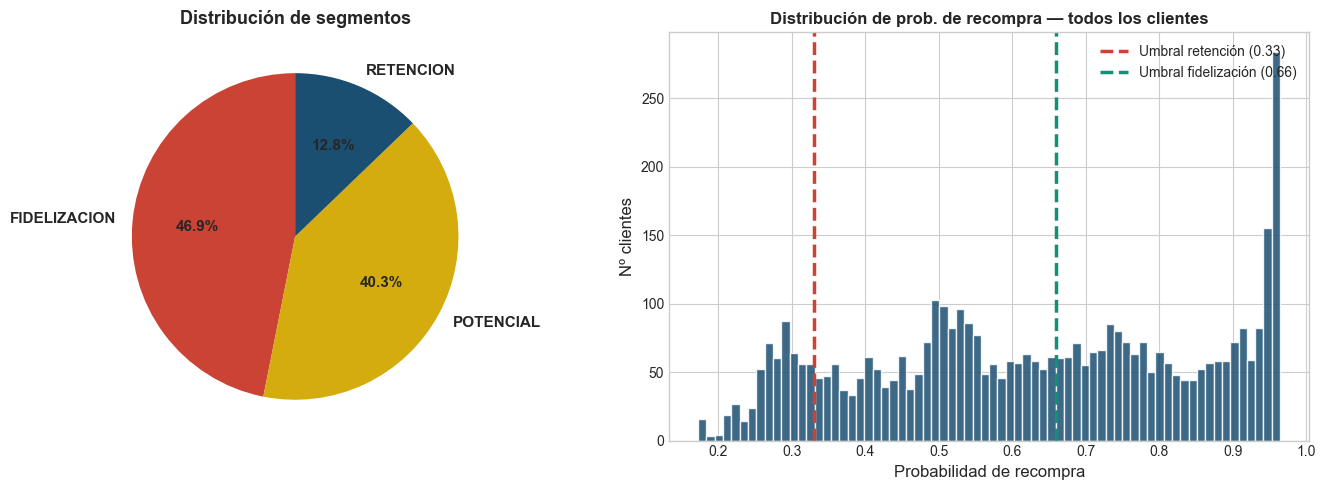

In [36]:
# Aplicar el modelo a todos los clientes del período de observación
X_all = feat[FEAT_COLS].fillna(0)
feat['prob_recompra'] = best_model.predict_proba(X_all)[:, 1]

# Segmentación en 3 grupos accionables
feat['segmento'] = pd.cut(
    feat['prob_recompra'],
    bins  = [0, 0.33, 0.66, 1.01],
    labels= ['RETENCION', 'POTENCIAL', 'FIDELIZACION']
)

print('=== Distribución de segmentos ===')
print(feat['segmento'].value_counts())

print('\n=== Perfil medio por segmento ===')
perfil_cols = ['recency_days','frequency','total_revenue','avg_ticket','unique_products','is_uk']
perfil = feat.groupby('segmento')[perfil_cols].mean().round(1)
print(perfil.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie de segmentos
seg_cnt = feat['segmento'].value_counts()
axes[0].pie(seg_cnt.values,
            labels=seg_cnt.index,
            colors=[PALETTE[3], PALETTE[2], PALETTE[0]],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Distribución de segmentos', fontweight='bold', fontsize=13)

# Histograma de probabilidades
axes[1].hist(feat['prob_recompra'], bins=70, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[1].axvline(0.33, color=PALETTE[3], ls='--', lw=2.5, label='Umbral retención (0.33)')
axes[1].axvline(0.66, color=PALETTE[1], ls='--', lw=2.5, label='Umbral fidelización (0.66)')
axes[1].set_xlabel('Probabilidad de recompra', fontsize=12)
axes[1].set_ylabel('Nº clientes', fontsize=12)
axes[1].set_title('Distribución de prob. de recompra — todos los clientes', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10)
plt.tight_layout(); plt.show()

In [37]:
# Exportar lista de clientes para CRM
export_cols = ['Customer ID','prob_recompra','segmento',
               'total_revenue','frequency','recency_days',
               'avg_ticket','unique_products','is_uk','purchase_rate']

output = (
    feat[export_cols]
    .sort_values('prob_recompra', ascending=False)
    .reset_index(drop=True)
)

output.to_csv('clientes_segmentados_recompra.csv', index=False)
print('✓ Exportado: clientes_segmentados_recompra.csv')
print(f'   Total clientes: {len(output):,}')
print()
print('Top 10 clientes con mayor probabilidad de recompra:')
output.head(10).to_string(index=False)

✓ Exportado: clientes_segmentados_recompra.csv
   Total clientes: 4,294

Top 10 clientes con mayor probabilidad de recompra:


' Customer ID  prob_recompra     segmento  total_revenue  frequency  recency_days  avg_ticket  unique_products  is_uk  purchase_rate\n       13077         0.9643 FIDELIZACION     2,640.0700          8             0    330.0087              144      1         0.0220\n       13013         0.9643 FIDELIZACION     9,343.1700         18             6    519.0650              224      1         0.0507\n       13590         0.9643 FIDELIZACION     4,354.1200         12            10    362.8433              225      1         0.0331\n       17091         0.9643 FIDELIZACION     4,254.8900         11             2    386.8082              165      1         0.0309\n       15298         0.9643 FIDELIZACION     5,057.0700         12             0    421.4225              145      1         0.0329\n       13050         0.9643 FIDELIZACION     6,700.2000         18             1    372.2333              407      1         0.0503\n       14796         0.9643 FIDELIZACION     3,536.2600         11  